In [1]:
import time
hrs = 3
time.sleep(60*60*2)

In [32]:
import pandas as pd
pd.set_option("display.max_columns", 400)
pd.set_option('display.max_colwidth', 4000)
pd.set_option("display.max_rows", 400)


import pandas as pd
from pathlib import Path
from sqlalchemy import create_engine
import re
import pickle
import os
from pathlib import Path
import string


from prefect import Flow, Parameter, task
from prefect import unmapped
import binpacking
import pickle

import networkx
# All parts in a flow
import itertools
import io
import json
import math
import os
import random
import shutil
import tempfile
import time
from datetime import datetime
from pathlib import Path
from typing import Dict, Generator, List

from os import listdir
from os.path import isfile, join
from datetime import date
import string
import shutil

import boto3
import numpy as np
import pandas as pd

import xlsxwriter

from sqlalchemy import create_engine

from common import sec
import psutil
from prefect import unmapped

#import awswrangler as wr
#import boto3
from prefect import Flow, Parameter, task
from prefect import unmapped
import binpacking
import pickle
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import networkx
# All parts in a flow
import itertools
import io
import json
import math
import os
import random
import shutil
import tempfile
import time
from datetime import datetime
from pathlib import Path
from typing import Dict, Generator, List

from os import listdir
from os.path import isfile, join

import string
import shutil
import awswrangler as wr
import boto3
import numpy as np
import pandas as pd
import prefect.executors
import xlsxwriter
from prefect import Flow, Parameter, task
from prefect.tasks.aws.s3 import S3Upload
from sqlalchemy import create_engine
import s3fs
from common import data_types
from common import new_bulkload as bl

# https://www.linuxbabe.com/command-line/create-ramdisk-linux
#sudo mkdir /tmp/ramdisk
#sudo chmod 777 /tmp/ramdisk
# sudo mount -t tmpfs -o size=500G myramdisk /tmp/ramdisk
# sudo umount /tmp/ramdisk/

from common import sec
import psutil
from prefect import unmapped
temp_base_location = "/tmp"
from prefect.engine.results.s3_result import S3Result
from prefect.executors.dask import LocalDaskExecutor
from prefect.run_configs.kubernetes import KubernetesRun
from prefect.storage import Docker
import oyaml


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

snowflake_db = "CPS_DB"
dn_key_name = "prd_cps_dsci_etl_svc"
schema = "CPS_DSCI_ARCHIVE"
warehouseMed = "cps_dsci_etl_wh"  # Medium
warehouseXsmall = "CPS_DSCI_ETL_EXT1_WH"  # X-Small
warehouseSmall = "CPS_DSCI_ETL_EXT2_WH"  # Small
@task(log_stdout=True)
def get_req_schema_from_source_names( this_file ):
    pa_this_schema =[]
    pyArrow_Remap_orig_col_to_dt = get_json_from_s3('canvas-data-types','pyarrow_col_data_type_map.json')
    meta = pq.read_metadata(this_file[0])
    for c in meta.schema.names :
        #print(c.lower())
        dt = pyArrow_Remap_orig_col_to_dt.get(c.lower(),'-')
        if dt == '-':
            dt = 'pa.string()'
        pa_this_schema.append(pa.field(c, eval(dt)))
    return pa.schema(pa_this_schema) 




temp_base_location = "/tmp"
snowflake_db = "CPS_DB"
dn_key_name = "prd_cps_dsci_etl_svc"
schema = "CPS_DSCI_ARCHIVE"
warehouseMed = "cps_dsci_etl_wh"  # Medium
warehouseXsmall = "CPS_DSCI_ETL_EXT1_WH"  # X-Small
warehouseSmall = "CPS_DSCI_ETL_EXT2_WH"  # Small
warehouseLarge = "CPS_DSCI_ETL_EXT3_WH"  # Small


def list_files_and_sizes(mypath, ext):
    file_nfo = []
    for filename in os.listdir(mypath):
        if filename.endswith(ext):
            fn_plus = os.path.join(mypath, filename)
            size = os.path.getsize(fn_plus)
            create_time = None
            try:
                create_time = time.ctime(os.path.getmtime(fn_plus))
                create_time= dt.datetime.strptime(create_time, "%a %b %d %H:%M:%S %Y")
                create_time= create_time.astimezone(dt.timezone.utc).timestamp()
            except:
                 pass
        file_nfo.append([mypath, filename, size, fn_plus,create_time])
    if len(file_nfo) > 0:
        return pd.DataFrame(file_nfo, columns=['path', 'file', 'size_of_file', 'path_plus_file', 'utc_create_epoc'])
    
    


import os
os.environ['ORACLE_HOME'] = "/usr/lib/oracle/12.2/client64"
os.environ['PATH'] = "/home/alanzen/bin:/home/alanzen/.local/bin:/home/alanzen/anaconda3/envs/env_3.7/bin:/home/alanzen/anaconda3/condabin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/usr/lib/oracle/12.2/client64/bin:/usr/lib/oracle/12.2/client64/lib"
os.environ['LD_LIBRARY_PATH'] = "/usr/lib/oracle/12.2/client64/lib:/usr/lib/oracle/12.2/client64"

def sync_with_gcp(src_dir,remote_dir):
    os.system("gsutil -m rsync -r {} {}".format(src_dir,remote_dir ))

import cx_Oracle

def fix_cols(df):
    cols = []
    for c in df.columns:
        cl = c.lower()
        cols.append(cl.strip().replace(' ','_').replace('/','_').replace('\\','_')  )
    return cols


local_store = "/mnt/newmt/ERP/home/alanzen/ACAT_FILES2/"
#l = "/mnt/newmt/ERP/home/alanzen/ACAT_FILES/"
remote_store = "gs://erp_core_data/acat_files/"


def get_completed_requests(local_store, ext='parquet'):
    done= list_files_and_sizes(local_store,ext)
    done_requests =[]
    for f in done.file:
        #print(f.split("_")[-2])
        try:
            #print(f)
            v = int(f.split("_")[-2])
        except Exception as e:
            print(e)
            pass
        finally:
            done_requests.append(v)
    return done_requests

snowflake_db = "CPS_DB"
dn_key_name = "prd_cps_dsci_etl_svc"
schema = "CPS_DSCI_ARCHIVE"
warehouseXsmall, 'cps_dsci_archive'
s_engine =  create_engine(sec.get_sf_pw(dn_key_name,warehouseXsmall,schema ))
#processed =  pd.read_sql('select distinct ACAT_REQUEST_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE', s_engine)  
processed =  pd.read_sql("select distinct REQUEST_ID from CPS_BIA_BR.DATA_CANVAS_DATA_SOURCES s where s.FILE_SOURCE = 'ACAT'", s_engine)  
processed.acat_request_id = processed.request_id.astype(int)
prior = set(processed.acat_request_id.values)


#now what do i really want to grab
real_sql = f"""SELECT d.request_id, customer_id, customer_name,total_lines,
        case when total_lines > 20000000 then 'YES' else 'NO' end as Source_manual,
        created_by, to_char(creation_date,'YYYY-MM-DD') as creation_date
        FROM APPS.XXCSS_ACAT_DISCOVERY_SUM D
        WHERE 1=1
        and  REQUEST_TYPE = 'ON-DEMAND'
        and data_purged like 'RETAIN%'
        and total_lines > 0
        and creation_date >  SYSDATE -5 """ 
#print(real_sql)

cr_engine =  create_engine(sec.acat_ro_connection)
real_data =  pd.read_sql(real_sql, cr_engine)  
real_data.request_id = real_data.request_id.astype(int)
avail = set(real_data.request_id.values)


to_do = list(avail.difference(prior))
real_data = real_data[real_data.request_id.isin(to_do)]    



@task(log_stdout=True, tags=['oracle_connection'])
def pull_thin_acat(work, dest_folder):
    request_id=work[0]
    src_date=work[3]
    cr_engine =  create_engine(sec.acat_ro_connection)
    out_name = os.path.join(f'{dest_folder}', f"{src_date}_{request_id}.parquet")
    print(out_name)
    sql = f"""select
        acat_request_id,
        instance_id,
        sweeps_customer_number,
        install_at_site_use_id,
        bill_to_site_use_id,
        ship_to_site_use_id,
        covered_line_id,
        atc_priority,
        offer_ato_suite_description,
        manual_exclusion_flag,
        delete_manual_exclusion_flag,
        unquotable_instructions_flag,
        config_covered_flag,
        rule_number,
        baseline_asset_status,
        earliest_discovery_date,
        atc_coverage_start_date,
        target_date_terminated,
        atc_coverage_end_date,
        exclude_flag,
        duplicate_ib_code,
        target_contract_number,
        target_service_line_name,
        target_install_site_id_flag,
        target_install_at_site_use_id,
        target_contract_bill_to_id,
        target_deal_id,
        acat_approval_flag,
        acat_status,
        aspt_quote_number,
        offer_ato_suite_name,
        reason_code,
        reference_id,
        sweeps_customer_name,
        sweeps_flag,
        case when ACAT_STATUS IN ('PENDING','MISSING-ATC','APPROVED','UNAPPROVED') then 1 else 0 end as OPPORTUNITY_NOT_EXCLUDED,
        case when COVERED_STATUS = 'A' AND EXCLUDE_FLAG  <> 'Y' AND MANUAL_EXCLUSION_FLAG = 'A' then 1 else 0 end as COVERED_IN_SCOPE_DATA,
        uncovered_category,
        case WHEN SHIP_DATE < AGGREEMENT_START_DATE THEN 'Shipped Pre-Agreement'
        WHEN SHIP_DATE > AGGREEMENT_START_DATE THEN 'Shipped Post Agreement'
        ELSE 'No Ship Date' END ship_category,
        d.REQUEST_TYPE,   -- added these 2-14-23
        d.ORDER_NUMBER    -- added these 2-14-23
        FROM APPS.XXCSS_ACAT_DISCOVERY_DATA a
        join APPS.XXCSS_ACAT_DISCOVERY_SUM D on (d.REQUEST_ID=a.ACAT_REQUEST_ID)
        join APPS.XXCSS_ACAT_CUSTOMER_MASTER m on (m.CUSTOMER_ID=D.CUSTOMER_ID)
        where ACAT_REQUEST_ID ={request_id}
        """
    if not os.path.exists(out_name):
        available_data =  pd.read_sql(sql, cr_engine)
        available_data.to_parquet( out_name, engine='pyarrow',compression='snappy',index =False)
    else:
        print(f"already done {out_name}")

/tmp/ipykernel_2797/1378074767.py:214: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  processed.acat_request_id = processed.request_id.astype(int)


In [33]:
print(real_data.shape)
real_data

(17, 7)


,request_id,customer_id,customer_name,total_lines,source_manual,created_by,creation_date
6,1676065113780,1663942515789,PFIZER INC,1742,NO,JEFTURNE,2023-02-10
98,1676374762458,1632305542421,ELISA AB,152920,NO,ARYNDUCH,2023-02-14
99,1676383134244,1653569912456,SEFE MARKETING & TRADING LIMITED,7225,NO,KVOLKOVA,2023-02-14
100,1676383134247,1642509709406,LONDON STOCK EXCHANGE GROUP,73174,NO,KVOLKOVA,2023-02-14
101,1676368745144,1615884584177,PARKER-HANNIFIN CORPORATION ROW,93281,NO,REGISILV,2023-02-14
102,1676382372034,1662650189391,PARKER-HANNIFIN CORPORATION US,54347,NO,REGISILV,2023-02-14
103,1676376302656,1615884584177,PARKER-HANNIFIN CORPORATION ROW,93008,NO,REGISILV,2023-02-14
104,1676380820693,1630937576423,G RESEARCH,6921,NO,NREGIMOW,2023-02-14
105,1676367067468,1614950102177,SMALS ASBL,7149,NO,ROSANFER,2023-02-14
106,1676359071944,1618468609524,NTT COMMUNICATION,110,NO,DUOWAN,2023-02-14


In [34]:
sql_pulls =[]
for i, row in real_data.iterrows():
    if row.source_manual=='NO':
        sql_pulls.append([row.request_id,row.customer_id,row.customer_name,row.creation_date ])
sql_pulls

[[1676065113780, 1663942515789, 'PFIZER INC', '2023-02-10'],
 [1676374762458, 1632305542421, 'ELISA AB', '2023-02-14'],
 [1676383134244,
  1653569912456,
  'SEFE MARKETING & TRADING LIMITED',
  '2023-02-14'],
 [1676383134247, 1642509709406, 'LONDON STOCK EXCHANGE GROUP', '2023-02-14'],
 [1676368745144,
  1615884584177,
  'PARKER-HANNIFIN CORPORATION ROW',
  '2023-02-14'],
 [1676382372034,
  1662650189391,
  'PARKER-HANNIFIN CORPORATION US',
  '2023-02-14'],
 [1676376302656,
  1615884584177,
  'PARKER-HANNIFIN CORPORATION ROW',
  '2023-02-14'],
 [1676380820693, 1630937576423, 'G RESEARCH', '2023-02-14'],
 [1676367067468, 1614950102177, 'SMALS ASBL', '2023-02-14'],
 [1676359071944, 1618468609524, 'NTT COMMUNICATION', '2023-02-14'],
 [1676368731517,
  1662650189391,
  'PARKER-HANNIFIN CORPORATION US',
  '2023-02-14'],
 [1676367076014,
  1643794189582,
  'SOCIETY FOR WORLDWIDE INTERBANK FINANCIAL TELECOMMUNICATIONS',
  '2023-02-14'],
 [1676370238577, 1676370062754, 'NETS DENMARK - 5 GU IDS

In [36]:
pd.to_datetime("today")

Timestamp('2023-02-14 14:08:28.421696')

In [37]:
# Vars:
#     date? for src folder i think so
#    dest_folder =  mkdir /mnt/newmt/ERP/home/alanzen/ACAT_SRC/{date}/
this_date = pd.to_datetime("today")
#overide when necessary
#this_date =  date(2023,2, 13)
this_date_str = this_date.strftime("%Y-%m-%d")
this_date_mod_str = this_date.strftime("%Y_%m_%d")
dest_folder = os.path.join('/mnt/newmt/ERP/home/alanzen/ACAT_SRC/',this_date_mod_str)
destination_loc = '/tmp/ramdisk/tmp_ram_drive'
dest_table = f'ACAT_EVIDENCE_part_{this_date_mod_str}'.lower()

print(this_date_str,dest_folder, dest_table)
Path( dest_folder).mkdir( parents=True, exist_ok=True )

2023-02-14 /mnt/newmt/ERP/home/alanzen/ACAT_SRC/2023_02_14 acat_evidence_part_2023_02_14


In [38]:
with Flow(
        "acat_daily",
        #storage=storage_obj,
        run_config=KubernetesRun(memory_request=60000000000),
        # executor=LocalDaskExecutor(scheduler="processes", num_workers=psutil.cpu_count(logical=True)),
        executor=LocalDaskExecutor(scheduler="processes", num_workers=4),
        result=S3Result(bucket="cam-prefect-results")
) as flow:
    pull_thin_acat.map(
        dest_folder= unmapped(dest_folder), 
        work=sql_pulls
    )
    
flow.visualize()

flow.run()


[2023-02-14 14:08:31+0000] INFO - prefect.FlowRunner | Beginning Flow run for 'acat_daily'
[2023-02-14 14:08:32+0000] INFO - prefect.TaskRunner | Task 'pull_thin_acat': Starting task run...
[2023-02-14 14:08:32+0000] INFO - prefect.TaskRunner | Task 'pull_thin_acat': Finished task run for task with final state: 'Mapped'
[2023-02-14 14:08:32+0000] INFO - prefect.TaskRunner | Task 'pull_thin_acat[11]': Starting task run...
[2023-02-14 14:08:32+0000] INFO - prefect.TaskRunner | /mnt/newmt/ERP/home/alanzen/ACAT_SRC/2023_02_14/2023-02-14_1676367076014.parquet
[2023-02-14 14:08:32+0000] INFO - prefect.TaskRunner | Task 'pull_thin_acat[10]': Starting task run...
[2023-02-14 14:08:33+0000] INFO - prefect.TaskRunner | /mnt/newmt/ERP/home/alanzen/ACAT_SRC/2023_02_14/2023-02-14_1676368731517.parquet
[2023-02-14 14:08:33+0000] INFO - prefect.TaskRunner | Task 'pull_thin_acat[1]': Starting task run...
[2023-02-14 14:08:33+0000] INFO - prefect.TaskRunner | Task 'pull_thin_acat[0]': Starting task run

<Success: "All reference tasks succeeded.">

In [8]:
#now process the files for data types so it could be bulk loaded

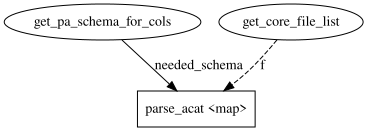

In [9]:
# old style
# def parse_file_name(f):    
#     try:
#         file_name = (f.split(os.sep))[-1]
#         fn_split = file_name.split('_')
#         #print(fn_split)
#         date = fn_split[-1].replace('.parquet','')
#         request_id = fn_split[-2]
#         customer_id= fn_split[-3]
#         return (date,request_id,customer_id)
#     except:
#         print(f"Error on {f}")
#         return(None, None, None)


@task(log_stdout=True)
def get_core_file_list(loc):
    thinned=[]
    if loc.startswith('s3://'):
        fls = wr.s3.list_objects(loc)
        for f in fls:
            if f.endswith('.parquet'):
                thinned.append(f)
    else:
        for i in os.listdir(loc):
            if  'parquet' in i:
                thinned.append(os.path.join(loc,i))
    print(f"thinned CORE FILES: {thinned}")
    return thinned

def parse_file_name(f):    
    try:
        file_name = (f.split(os.sep))[-1]
        req = file_name.replace('.parquet','')
        #fn_split = file_name.split('_')
        #print(fn_split)
        #date = fn_split[-1].replace('.parquet','')
        #request_id = fn_split[-2]
        #customer_id= fn_split[-3]
        return ('2022-06-02',req,-1)
    except:
        print(f"Error on {f}")
        return(None, None, None)

def parse_file_name(f):    
    try:
        file_name = (f.split(os.sep))[-1]
        fn_split = file_name.split('_')
        #print(fn_split)
        date = fn_split[-2]
        request_id = fn_split[-1].replace('.parquet','')
        customer_id=-1
        return (date,request_id,customer_id)
    except:
        print(f"Error on {f}")
        return(None, None, None)
        
    
    
@task(log_stdout=True)       
def get_pa_schema_for_cols( thin_cols, extra_col_def ):
    pa_this_schema =[]
    pyArrow_Remap_orig_col_to_dt = get_json_from_s3('canvas-data-types','pyarrow_col_data_type_map.json')
    for c in thin_cols :
        dt = pyArrow_Remap_orig_col_to_dt.get(c.lower(),'-')
        if dt == '-':
            dt = 'pa.string()'
        pa_this_schema.append(pa.field(c, eval(dt)))
    for xc in extra_col_def:
        pa_this_schema.append(pa.field(xc[0], eval(xc[1])))    
    return pa.schema(pa_this_schema)     

    
@task(log_stdout=True)    
def parse_acat(f, acat_fields,destination_loc,needed_schema ):    
    
    file_date, file_acat_request, file_customer_id = parse_file_name(f)
    out_name = os.path.join(destination_loc,f"{file_acat_request}.parquet")
    cn = check_env('prod')
    try:
        if not os.path.exists(out_name):
            df = pa.parquet.read_pandas(f,columns=acat_fields).to_pandas()
            df = prep_data(df, 'src')
            #df[acat_fields] = df[acat_fields].astype(str)
            df['file_name_date']= file_date    
            df['file_name_acat_request_id']= int(file_acat_request)
            df['file_name_customer_id']= df['sweeps_customer_number']    

            if 'offer_ato_suite_description' not in df.columns:
                    df['offer_ato_suite_description']= ''

            if 'atc_coverage_end_date' in df.columns:
                df['atc_coverage_end_date'] = pd.to_datetime(df['atc_coverage_end_date'], errors='coerce').dt.date

            if 'file_name_date' in df.columns:
                df['file_name_date'] = pd.to_datetime(df['file_name_date'], errors='coerce').dt.date

            if 'earliest_discovery_date' in df.columns:
                df['earliest_discovery_date'] = pd.to_datetime(df['earliest_discovery_date'], errors='coerce').dt.date

            if 'acat_request_id' in df.columns:
                df['acat_request_id']= df['acat_request_id'].replace(['nan', 'None','<NA>', np.nan],-1)

            if 'sweeps_customer_number' in df.columns:
                df['sweeps_customer_number']= df['sweeps_customer_number'].replace(['nan', 'None','<NA>', np.nan],-1)

            if 'install_at_site_use_id' in df.columns:
                df['install_at_site_use_id']= df['install_at_site_use_id'].replace(['nan', 'None','<NA>', np.nan],-1)

            if 'bill_to_site_use_id' in df.columns:
                df['bill_to_site_use_id']= df['bill_to_site_use_id'].replace(['nan', 'None','<NA>', np.nan],-1)

            if 'ship_to_site_use_id' in df.columns:
                df['ship_to_site_use_id']= df['ship_to_site_use_id'].replace(['nan', 'None','<NA>', np.nan],-1)

            if 'covered_line_id' in df.columns:
                df['covered_line_id']= df['covered_line_id'].replace(['nan', 'None','<NA>', np.nan],-1)

            if 'atc_priority' in df.columns:
                df['atc_priority']= df['atc_priority'].replace(['nan', 'None','<NA>', np.nan],-1)

            if 'offer_ato_suite_description' in df.columns:
                df['offer_ato_suite_description']= df['offer_ato_suite_description'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'opportunity_not_excluded' in df.columns:
                df['opportunity_not_excluded']= df['opportunity_not_excluded'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'delete_manual_exclusion_flag' in df.columns:
                df['delete_manual_exclusion_flag']= df['delete_manual_exclusion_flag'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'unquotable_instructions_flag' in df.columns:
                df['unquotable_instructions_flag']= df['unquotable_instructions_flag'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'config_covered_flag' in df.columns:
                df['config_covered_flag']= df['config_covered_flag'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'rule_number' in df.columns:
                df['rule_number']= df['rule_number'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'baseline_asset_status' in df.columns:
                df['baseline_asset_status']= df['baseline_asset_status'].replace(['nan', 'None','<NA>', np.nan],'')


            if 'atc_coverage_start_date' in df.columns:
                df['atc_coverage_start_date']= df['atc_coverage_start_date'].replace(['nan', 'None','<NA>', np.nan],np.nan)

            if 'target_date_terminated' in df.columns:
                df['target_date_terminated']= df['target_date_terminated'].replace(['nan', 'None','<NA>', np.nan],np.nan)

            if 'atc_coverage_end_date' in df.columns:
                df['atc_coverage_end_date']= df['atc_coverage_end_date'].replace(['nan', 'None','<NA>', np.nan],np.nan)

            if 'exclude_flag' in df.columns:
                df['exclude_flag']= df['exclude_flag'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'duplicate_ib_code' in df.columns:
                df['duplicate_ib_code']= df['duplicate_ib_code'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'target_contract_number' in df.columns:
                df['target_contract_number']= df['target_contract_number'].replace(['nan', 'None','<NA>', np.nan],np.nan)

            if 'target_service_line_name' in df.columns:
                df['target_service_line_name']= df['target_service_line_name'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'target_install_site_id_flag' in df.columns:
                df['target_install_site_id_flag']= df['target_install_site_id_flag'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'target_install_at_site_use_id' in df.columns:
                df['target_install_at_site_use_id']= df['target_install_at_site_use_id'].replace(['nan', 'None','<NA>', np.nan],-1)

            if 'target_contract_bill_to_id' in df.columns:
                df['target_contract_bill_to_id']= df['target_contract_bill_to_id'].replace(['nan', 'None','<NA>', np.nan],-1)

            if 'target_deal_id' in df.columns:
                df['target_deal_id']= df['target_deal_id'].replace(['nan', 'None','<NA>', np.nan],-1)

            if 'acat_approval_flag' in df.columns:
                df['acat_approval_flag']= df['acat_approval_flag'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'acat_status' in df.columns:
                df['acat_status']= df['acat_status'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'aspt_quote_number' in df.columns:
                df['aspt_quote_number']= df['aspt_quote_number'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'baseline_asset_status' in df.columns:
                df['baseline_asset_status']= df['baseline_asset_status'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'offer_ato_suite_name' in df.columns:
                df['offer_ato_suite_name']= df['offer_ato_suite_name'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'reason_code' in df.columns:
                df['reason_code']= df['reason_code'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'reference_id' in df.columns:
                df['reference_id']= df['reference_id'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'sweeps_customer_name' in df.columns:
                df['sweeps_customer_name']= df['sweeps_customer_name'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'sweeps_flag' in df.columns:
                df['sweeps_flag']= df['sweeps_flag'].replace(['nan', 'None','<NA>', np.nan],'')
            
            if 'uncovered_category' in df.columns:
                df['uncovered_category']= df['uncovered_category'].replace(['nan', 'None','<NA>', np.nan],'')
        
            if 'ship_category' in df.columns:
                df['ship_category']= df['ship_category'].replace(['nan', 'None','<NA>', np.nan],'')
                
            if 'request_type' in df.columns:
                df['request_type']= df['request_type'].replace(['nan', 'None','<NA>', np.nan],'')

            if 'order_number' in df.columns:
                df['order_number']= df['order_number'].replace(['nan', 'None','<NA>', np.nan],'')

   

            df = prep_data(df, 'src')

            if df.shape[0] > 0:
                table = pa.Table.from_pandas(df, schema=needed_schema, preserve_index=False)
                with pq.ParquetWriter(out_name, needed_schema, compression='snappy', allow_truncated_timestamps=True) as writer:
                    writer.write_table(table)    
                print(f,file_acat_request,out_name, df.shape[0], df.shape[1])
            else:
                print(f"empty file :{f}")
        else:
            print(f"already have {f}")
        
    except Exception as e: 
        print(e)
        out_name = os.path.join(destination_loc,'err', f"{file_acat_request}.parquet")
        print(f"FAIL : {f} , {df.shape}     {df.columns.values}")
        df.to_parquet(out_name,
                engine="pyarrow",
                compression="snappy",
                index=False,
                allow_truncated_timestamps=True,
                coerce_timestamps="ms")
        print("---------------------------------------------------------------------------------------")
        print("---------------------------------------------------------------------------------------")
            
    return True

with Flow('proc_acat',
        run_config=KubernetesRun(),
        executor=LocalDaskExecutor(scheduler="processes", num_workers=15)
         ) as process_acat:
    broken=[]
    stats=[]
    acat_fields = ['acat_request_id',
     'instance_id', 
     'sweeps_customer_number',
     'install_at_site_use_id',
     'bill_to_site_use_id',
     'ship_to_site_use_id',
     'covered_line_id',
     'atc_priority',
     'offer_ato_suite_description',
      
    'opportunity_not_excluded',
    'covered_in_scope_data',
     
    'manual_exclusion_flag', 
    'delete_manual_exclusion_flag',
    'unquotable_instructions_flag',
    'config_covered_flag',
    'rule_number',
    'baseline_asset_status',
    'earliest_discovery_date',
    'atc_coverage_start_date',
    'target_date_terminated',
    'atc_coverage_end_date',
    'exclude_flag',
    'duplicate_ib_code',
    'target_contract_number',
    'target_service_line_name',
    'target_install_site_id_flag',
    'target_install_at_site_use_id',
    'target_contract_bill_to_id',
    'target_deal_id',
    'acat_approval_flag',
    'acat_status',
    'aspt_quote_number',
    'offer_ato_suite_name',
    'reason_code',
    'reference_id',
    'sweeps_customer_name',
    'sweeps_flag',
    'uncovered_category',
    'ship_category',
    'request_type',
    'order_number'
        ]
    
    # uncovered_category  add it here, plus date tyoe and add it to the master 
    #
    #CASE 
#     WHEN GREATEST(NVL(END_DATE,'01-JAN-1901'),NVL(SHIP_DATE,'01-JAN-1901'),NVL(AGGREEMENT_START_DATE,'01-JAN-1901'),NVL(EARLIEST_DISCOVERY_DATE,'01-JAN-1901')) = SHIP_DATE THEN 'New shipment'
#     WHEN GREATEST(NVL(END_DATE,'01-JAN-1901'),NVL(SHIP_DATE,'01-JAN-1901'),NVL(AGGREEMENT_START_DATE,'01-JAN-1901')) = SHIP_DATE AND EARLIEST_DISCOVERY_DATE = TRUNC(EARLIEST_DISCOVERY_DATE) AND EARLIEST_DISCOVERY_DATE - SHIP_DATE < 60 THEN 'New shipment'    
#     WHEN GREATEST(NVL(END_DATE,'01-JAN-1901'),NVL(SHIP_DATE,'01-JAN-1901'),NVL(AGGREEMENT_START_DATE,'01-JAN-1901'),NVL(EARLIEST_DISCOVERY_DATE,'01-JAN-1901')) = EARLIEST_DISCOVERY_DATE THEN 'Uncovered new discovery'
#     WHEN COVERED_STATUS = 'A' THEN 'Covered'
#     WHEN GREATEST(NVL(END_DATE,'01-JAN-1901'),NVL(SHIP_DATE,'01-JAN-1901'),NVL(AGGREEMENT_START_DATE,'01-JAN-1901'),NVL(EARLIEST_DISCOVERY_DATE,'01-JAN-1901')) = END_DATE AND STS_CODE = 'EXPIRED' THEN 'Expired from coverage'
#     WHEN GREATEST(NVL(END_DATE,'01-JAN-1901'),NVL(SHIP_DATE,'01-JAN-1901'),NVL(AGGREEMENT_START_DATE,'01-JAN-1901'),NVL(EARLIEST_DISCOVERY_DATE,'01-JAN-1901')) = END_DATE AND STS_CODE = 'TERMINATED' THEN 'Terminated from coverage'
#     WHEN GREATEST(NVL(END_DATE,'01-JAN-1901'),NVL(SHIP_DATE,'01-JAN-1901'),NVL(AGGREEMENT_START_DATE,'01-JAN-1901'),NVL(EARLIEST_DISCOVERY_DATE,'01-JAN-1901')) = AGGREEMENT_START_DATE THEN 'Uncovered since agreement'    
# END UNCOVERED_BY


# CASE WHEN D.SHIP_DATE < M.AGGREEMENT_START_DATE THEN 'Shipped Pre-Agreement' WHEN D.SHIP_DATE > M.AGGREEMENT_START_DATE THEN 'Shipped Post Agreement' ELSE 'No Ship Date' END SHIP_CATEGORY
    #
    
    
    extra_columns=[]    
    extra_columns.append(("file_name_date",'pa.date32()'))
    extra_columns.append(("file_name_acat_request_id",'pa.int64()'))
    extra_columns.append(("file_name_customer_id",'pa.string()'))

    needed_schema = get_pa_schema_for_cols(acat_fields,extra_columns)
    
    root = dest_folder
    fls = get_core_file_list(root)
    parse_acat.map(
        f=fls,
    acat_fields=unmapped(acat_fields),
        destination_loc=unmapped(destination_loc),
        needed_schema=unmapped(needed_schema)
        
    )
    
    

process_acat.visualize()      

In [10]:
def get_json_from_s3(bucket,key):
    s3 = boto3.resource('s3')
    obj = s3.Object(bucket, key)
    data = obj.get()['Body'].read().decode('utf-8')
    json_data = oyaml.safe_load(data) 
    return json_data

#@task(log_stdout=True)
def check_env(env):
    print(env)
    if env == "dev":
        cn = "dev_cps_dsci_etl_svc"
    elif env == "stage":
        cn = "stg_cps_dsci_etl_svc"
    elif env == "prod":
        cn = "prd_cps_dsci_etl_svc"
    return cn


def fix_cols(df):
    cols = []
    for c in df.columns:
        cl = c.lower()
        cols.append(cl.strip().replace(' ','_').replace('/','_').replace('\\','_').replace('-','_')   )
    return cols



def rename_standard_cols(df):
#         rename_map = dict(zip(standard_df.col, standard_df.real_name))  #cant use show bc wa only know wheat we DO NOT weant to sheo
        rename_map = get_json_from_s3('canvas-data-types','canvas_col_rename.json')
        df.rename(columns=rename_map, inplace=True)
        return df
    

def rename_canvas_create_cols(df):
#         rename_map = dict(zip(standard_df.col, standard_df.real_name))  #cant use show bc wa only know wheat we DO NOT weant to sheo
        rename_map = get_json_from_s3('canvas-data-types','canvas_prep_final_name_map.json')
        df.rename(columns=rename_map, inplace=True)
        return df    
    
def remove_hidden_cols(df):    
    hidden_cols = get_json_from_s3('canvas-data-types','canvas_cols_to_be_hidden.json')
    hidden_list = list(set(df.columns).intersection(set(hidden_cols)))
    #print(df.shape)
    df.drop(hidden_list, axis = 1, inplace=True)
    #print(df.shape) 
    return df

def get_json_from_s3(bucket,key):
    s3 = boto3.resource('s3')
    obj = s3.Object(bucket, key)
    data = obj.get()['Body'].read().decode('utf-8')
    json_data = oyaml.safe_load(data) 
    return json_data



def fix_numbers(s):
    s= pd.to_numeric(s.convert_dtypes(), errors='coerce')
    s= pd.to_numeric(s, errors='coerce').convert_dtypes()
    return s


def prep_data(df, ref="na"):
    
    if ref == 'src':
        pandas_data_type_map = get_json_from_s3('canvas-data-types','pre_rename_sql_data_type_map.json') 
    elif ref == 'post':
        pandas_data_type_map = get_json_from_s3('canvas-data-types','pandas_data_type_map.json') 
    else:
        pandas_data_type_map = get_json_from_s3('canvas-data-types','pandas_data_type_map.json')             
    
    for k in df.columns:
        #print(k,pandas_data_type_map.get(k, 'GO DEFINE IT') )
        if pandas_data_type_map.get(k, 'xxxxx')  in ["Int64", "float64", "int"]:  # "str" had this
            df[k] = fix_numbers(df[k])
        elif pandas_data_type_map.get(k, 'xxxxx')  in ["datetime64[ns]"]:
            df[k] = pd.to_datetime(df[k], errors='coerce').dt.date
        elif pandas_data_type_map.get(k, 'xxxxx')  in ["str"]:
            df[k] = df[k].astype("str")
        else:
            df[k] = df[k].astype("str")
    df=df.replace(['nan', 'None','<NA>'], np.nan)
    return df


In [11]:
dest_folder

'/mnt/newmt/ERP/home/alanzen/ACAT_SRC/2023_02_13'

In [12]:
process_acat.run()

[2023-02-13 22:41:43+0000] INFO - prefect.FlowRunner | Beginning Flow run for 'proc_acat'
[2023-02-13 22:41:43+0000] INFO - prefect.TaskRunner | Task 'get_pa_schema_for_cols': Starting task run...
[2023-02-13 22:41:44+0000] INFO - prefect.TaskRunner | Task 'get_pa_schema_for_cols': Finished task run for task with final state: 'Success'
[2023-02-13 22:41:44+0000] INFO - prefect.TaskRunner | Task 'get_core_file_list': Starting task run...
[2023-02-13 22:41:44+0000] INFO - prefect.TaskRunner | thinned CORE FILES: ['/mnt/newmt/ERP/home/alanzen/ACAT_SRC/2023_02_13/2023-02-10_1675994141915.parquet', '/mnt/newmt/ERP/home/alanzen/ACAT_SRC/2023_02_13/2023-02-10_1676068590767.parquet', '/mnt/newmt/ERP/home/alanzen/ACAT_SRC/2023_02_13/2023-02-10_1676045308135.parquet', '/mnt/newmt/ERP/home/alanzen/ACAT_SRC/2023_02_13/2023-02-10_1676067812513.parquet', '/mnt/newmt/ERP/home/alanzen/ACAT_SRC/2023_02_13/2023-02-10_1676016601715.parquet', '/mnt/newmt/ERP/home/alanzen/ACAT_SRC/2023_02_13/2023-02-13_167

<Success: "All reference tasks succeeded.">

In [13]:
dest_table

'acat_evidence_part_2023_02_13'

In [14]:
destination_loc

'/tmp/ramdisk/tmp_ram_drive'

In [15]:
# this_date = pd.to_datetime("today")
# this_date_str = this_date.strftime("%Y-%m-%d")
# this_date_mod_str = this_date.strftime("%Y_%m_%d")
# dest_folder = os.path.join('/mnt/newmt/ERP/home/alanzen/ACAT_SRC/',this_date_mod_str)


bl.generic_bulk_load_snowflake(destination_loc,
                   'CPS_DSCI_ARCHIVE',
                   dest_table.lower(), 
                   check_env('prod'), 
                   warehouseMed, 
                   create_table_from_file=True,  truncate_table=True)

prod


/home/alanzen/.cache/pypoetry/virtualenvs/hnms-aws-F0wIgF5s-py3.8/lib/python3.8/site-packages/pandas/io/sql.py:857: SAWarning: Dialect snowflake:snowflake will not make use of SQL compilation caching as it does not set the 'supports_statement_cache' attribute to ``True``.  This can have significant performance implications including some performance degradations in comparison to prior SQLAlchemy versions.  Dialect maintainers should seek to set this attribute to True after appropriate development and testing for SQLAlchemy 1.4 caching support.   Alternatively, this attribute may be set to False which will disable this warning. (Background on this error at: https://sqlalche.me/e/14/cprf)
  result = conn.execute(self.table.insert(), data)
/mnt/newmt/ERP/home/alanzen/canvas_prep_flatten_store/common/new_bulkload.py:83: SAWarning: Dialect snowflake:snowflake will not make use of SQL compilation caching as it does not set the 'supports_statement_cache' attribute to ``True``.  This can have 

dest_table.c
ImmutableColumnCollection(acat_evidence_part_2023_02_13.acat_request_id, acat_evidence_part_2023_02_13.instance_id, acat_evidence_part_2023_02_13.sweeps_customer_number, acat_evidence_part_2023_02_13.install_at_site_use_id, acat_evidence_part_2023_02_13.bill_to_site_use_id, acat_evidence_part_2023_02_13.ship_to_site_use_id, acat_evidence_part_2023_02_13.covered_line_id, acat_evidence_part_2023_02_13.atc_priority, acat_evidence_part_2023_02_13.offer_ato_suite_description, acat_evidence_part_2023_02_13.opportunity_not_excluded, acat_evidence_part_2023_02_13.covered_in_scope_data, acat_evidence_part_2023_02_13.manual_exclusion_flag, acat_evidence_part_2023_02_13.delete_manual_exclusion_flag, acat_evidence_part_2023_02_13.unquotable_instructions_flag, acat_evidence_part_2023_02_13.config_covered_flag, acat_evidence_part_2023_02_13.rule_number, acat_evidence_part_2023_02_13.baseline_asset_status, acat_evidence_part_2023_02_13.earliest_discovery_date, acat_evidence_part_2023_02_

In [16]:
#00ps  when you need to re-run and dotn want to dbl load
#print(f"delete from CPS_DSCI_ARCHIVE.ACAT_SCOPE where ACAT_REQUEST_ID in (select ACAT_REQUEST_ID from {dest_table})")

In [17]:
#LOTS OF SQL on 28


batch_val =this_date_mod_str
from_tbl = f'CPS_DSCI_ARCHIVE.{dest_table.upper()}'



sql_post_proc_sql = f"""
use warehouse CPS_DSCI_ETL_EXT3_WH;
set batch_val ='{batch_val}';
set segment = 1;
set segments_needed = 1;
set cvd = concat('CPS_DSCI_ARCHIVE.cvd_lines_all_acat_batch_',$batch_val);
set dest = concat('CPS_DSCI_ARCHIVE.test_acat_evidence_b_',$batch_val, '_to_file_',$segment);
set acat = concat('CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_',$batch_val);
set notes_tbl = concat('CPS_DSCI_ARCHIVE.acat_notes_b_',$batch_val, '_to_s',$segment);


-- manage acat scope table
insert into CPS_DSCI_ARCHIVE.ACAT_SCOPE (ACAT_REQUEST_ID, CUSTOMER_ID,INSTANCE_ID )
select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID 
from {from_tbl} e;

create or replace table CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_picker as
select count(0) row_cnt , ACAT_REQUEST_ID
from IDENTIFIER($acat) e  group by ACAT_REQUEST_ID;

alter table CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PICKER add column segment int;
update CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PICKER set segment = uniform(1, $segments_needed, random());

create or replace table  IDENTIFIER ($cvd) as
    with sub as (
        select distinct covered_line_id from IDENTIFIER ($acat) a
    )
select cvd_line.* from EDW_SERVICE_ETL_DB.ss.CSF_XXCCS_DS_CVDPRDLINE_DETAIL cvd_line
    join sub on sub.covered_line_id=cvd_line.COVERED_LINE_ID;

insert into IDENTIFIER($cvd)(
       COVERED_LINE_ID,            INSTANCE_ID, LSE_ID, OBJECT_CODE, CONTRACT_ID, SERVICE_LINE_ID, STS_CODE, START_DATE, END_DATE, CLE_ID_RENEWED, CLE_ID_RENEWED_TO, DNR_FLAG, PRICE_NEGOTIATED, PRICE_UNIT, PBS_FLAG, MAINTENANCE_PO_NUMBER, MAINTENANCE_SO_NUMBER, DATE_TERMINATED, LINE_NUMBER, TRN_CODE, LINE_CREATION_DATE, LINE_LAST_UPDATE_DATE, LINE_CREATED_BY, LINE_LAST_UPDATED_BY, CURRENCY_CODE, DATE_RENEWED, CVD_ATTRIBUTE1, CVD_ATTRIBUTE2, CVD_ATTRIBUTE3, CVD_ATTRIBUTE4, CVD_ATTRIBUTE5, CVD_ATTRIBUTE6, CVD_ATTRIBUTE7, CVD_ATTRIBUTE8, CVD_ATTRIBUTE9, CVD_ATTRIBUTE10, CVD_ATTRIBUTE11, CVD_ATTRIBUTE12, CVD_ATTRIBUTE13, CVD_ATTRIBUTE14, CVD_ATTRIBUTE15, ENTITLED_START_DATE, ENTITLED_END_DATE, NRT_CREATION_DATE, NRT_CREATED_BY, NRT_LAST_UPDATE_DATE, NRT_LAST_UPDATED_BY, NRT_REQUEST_ID, NRT_PROGRAM_ID, NUMBER_OF_ITEMS, INVENTORY_ITEM_ID, PRODUCT_LABEL, PRODUCT_NOTES, DUPLICATE_COVERAGE_FLAG, DUPLICATE_CVG_REF_LINE_ID, USD_PRICE_NEGOTIATED, USD_PRICE_UNIT, USD_CONVERSION_RATE, COVERED_LINE_MOVED_FROM, COVERED_LINE_MOVED_TO, SAVA, MAPPED_SKU, ARCHITECTURE, TECHNOLOGY, OFFER_TYPE, DEAL_END_CR_PARTY_ID, PRODUCT_CLASS, ACTUAL_PRICE_NEGOTIATED, PROGRAM_TYPE, END_DATE_FISCAL_PERIOD, RENEWED_FLAG, RENEWAL_ELIGIBLE_FLAG, SERVICE_TYPE, ORIGINAL_TRN_CODE, MULTI_SO_LINE, MULTI_SO_LINE_TYPE, QUOTE_NUMBER, QUOTE_TYPE, EXTERNAL_SERVICE_SO_NUMBER, EXTERNAL_SERVICE_SO_LINE_ID, ORDER_SOURCE_ID, ORDER_ORIGIN, PROPOSAL_ID, OFFER_ATO_SUITE_NAME, OFFER_TRANSACTION_TYPE, SO_NUMBER_SOURCE_SYSTEM, SO_LINE_ID_SOURCE_SYSTEM, INVOICE_ELIGIBLE_FLAG, SERVICE_FEE_START_DATE, CREDIT_FREE_COVERAGE, TERMINATION_CREDIT )
with sub as ( -- missing
        select distinct a.covered_line_id from IDENTIFIER($acat) a
        left join EDW_SERVICE_ETL_DB.ss.CSF_XXCCS_DS_CVDPRDLINE_DETAIL cvd_line on (cvd_line.COVERED_LINE_ID=a.COVERED_LINE_ID)
        where cvd_line.COVERED_LINE_ID is null
    )
select cvd_line_h.COVERED_LINE_ID, INSTANCE_ID, LSE_ID, OBJECT_CODE, CONTRACT_ID, SERVICE_LINE_ID, STS_CODE, START_DATE, END_DATE, CLE_ID_RENEWED, CLE_ID_RENEWED_TO, DNR_FLAG, PRICE_NEGOTIATED, PRICE_UNIT, PBS_FLAG, MAINTENANCE_PO_NUMBER, MAINTENANCE_SO_NUMBER, DATE_TERMINATED, LINE_NUMBER, TRN_CODE, LINE_CREATION_DATE, LINE_LAST_UPDATE_DATE, LINE_CREATED_BY, LINE_LAST_UPDATED_BY, CURRENCY_CODE, DATE_RENEWED, CVD_ATTRIBUTE1, CVD_ATTRIBUTE2, CVD_ATTRIBUTE3, CVD_ATTRIBUTE4, CVD_ATTRIBUTE5, CVD_ATTRIBUTE6, CVD_ATTRIBUTE7, CVD_ATTRIBUTE8, CVD_ATTRIBUTE9, CVD_ATTRIBUTE10, CVD_ATTRIBUTE11, CVD_ATTRIBUTE12, CVD_ATTRIBUTE13, CVD_ATTRIBUTE14, CVD_ATTRIBUTE15, ENTITLED_START_DATE, ENTITLED_END_DATE, NRT_CREATION_DATE, NRT_CREATED_BY, NRT_LAST_UPDATE_DATE, NRT_LAST_UPDATED_BY, NRT_REQUEST_ID, NRT_PROGRAM_ID, NUMBER_OF_ITEMS, INVENTORY_ITEM_ID, PRODUCT_LABEL, PRODUCT_NOTES, DUPLICATE_COVERAGE_FLAG, DUPLICATE_CVG_REF_LINE_ID, USD_PRICE_NEGOTIATED, USD_PRICE_UNIT, USD_CONVERSION_RATE, COVERED_LINE_MOVED_FROM, COVERED_LINE_MOVED_TO, SAVA, MAPPED_SKU, ARCHITECTURE, TECHNOLOGY, OFFER_TYPE, DEAL_END_CR_PARTY_ID, PRODUCT_CLASS, ACTUAL_PRICE_NEGOTIATED, PROGRAM_TYPE, END_DATE_FISCAL_PERIOD, RENEWED_FLAG, RENEWAL_ELIGIBLE_FLAG, SERVICE_TYPE, ORIGINAL_TRN_CODE, MULTI_SO_LINE, MULTI_SO_LINE_TYPE, QUOTE_NUMBER, QUOTE_TYPE, EXTERNAL_SERVICE_SO_NUMBER, EXTERNAL_SERVICE_SO_LINE_ID, ORDER_SOURCE_ID, ORDER_ORIGIN, PROPOSAL_ID, OFFER_ATO_SUITE_NAME, OFFER_TRANSACTION_TYPE, SO_NUMBER_SOURCE_SYSTEM, SO_LINE_ID_SOURCE_SYSTEM, INVOICE_ELIGIBLE_FLAG, SERVICE_FEE_START_DATE, CREDIT_FREE_COVERAGE, TERMINATION_CREDIT
    from EDW_SERVICE_ETL_DB.ss.CSF_XXCCS_DS_CVDPRDLINE_DETAIL_H cvd_line_h
        join sub on (sub.COVERED_LINE_ID= cvd_line_h.COVERED_LINE_ID);

create or replace table IDENTIFIER($dest) as
    with resolved_eol as (
        select eol.BK_END_OF_LIFE_REQUEST_NUM,
               eol.BK_PRODUCT_ID,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.END_OF_CHANGE_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')    as END_OF_CHANGE_DT,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.END_OF_MANUFACTURING_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')   as END_OF_MANUFACTURING_DT,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.END_OF_NEW_SVC_ATTACHMENT_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')  as END_OF_NEW_SVC_ATTACHMENT_DT,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.END_OF_SOFTWARE_MAINTENANCE_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')  as END_OF_SOFTWARE_MAINTENANCE_DT,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.END_OF_ROUTINE_FAIL_ANLYSYS_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')  as END_OF_ROUTINE_FAIL_ANLYSYS_DT,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.END_OF_SALE_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')   as END_OF_SALE_DT,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.EOL_SOFTWARE_AVAILABLE_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')     as EOL_SOFTWARE_AVAILABLE_DT,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.END_OF_SFTWR_LICENSE_AVAIL_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')     as END_OF_SFTWR_LICENSE_AVAIL_DT,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.EOL_SIGNATURE_RELEASE_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')   as EOL_SIGNATURE_RELEASE_DT,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.END_OF_SVC_CONTRACT_RNWL_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')   as END_OF_SVC_CONTRACT_RNWL_DT,
               TO_CHAR(CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(gp.END_OF_TAC_ENGG_SUPPORT_DT::DATE, '2150-12-31'::DATE),'yyyy-mm-dd')      as END_OF_TAC_ENGG_SUPPORT_DT,
               rank() over ( partition by eol.BK_PRODUCT_ID order by eol.BK_END_OF_LIFE_REQUEST_NUM desc,eol.EDW_CREATE_DATETIME desc ) as orderv
        from CPS_DB.CPS_DSCI_EBV.BV_END_OF_LIFE_PRODUCT eol
                 join CPS_DB.CPS_DSCI_EBV.BV_EOL_BULLETIN_MILESTONE_GROUP gp
                      ON   (
                                  gp.BK_END_OF_LIFE_REQUEST_NUM = eol.BK_END_OF_LIFE_REQUEST_NUM
                              and
                                  gp.BK_EOL_BULLETIN_PRODUCT_TYP_CD = eol.BK_EOL_BULLETIN_PRODUCT_TYP_CD
                              and
                                   nvl(gp.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                              and
                                  nvl(gp.SOURCE_DELETED_FLG, 'N') = 'N'
                              and
                                  nvl(eol.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                              and
                                  nvl(eol.SOURCE_DELETED_FLG, 'N') = 'N'
                          )
     )  SELECT distinct IB.instance_id,                                                                                                                             --80
               IB.instance_number,                                                                                                                         -- 81
               ib.deal_id,                                                                                                                                 --45
               nvl(cvd_line.USD_PRICE_UNIT, cvd_line.PRICE_UNIT)                                                     as usd_prorated_list_price,           --504
               nvl(cvd_line.USD_PRICE_UNIT, cvd_line.PRICE_UNIT) * ib.QUANTITY                                       as usd_extended_list_price,           -- 505
               ib.PARENT_INSTANCE_ID,                                                                                                                      --108 -- 309
               IB.covered_status,                                                                                                                          --219 , 42
               --CASE WHEN ib.covered_status = 'A' THEN 'COVERED' ELSE 'UNCOVERED' END                                 as coverage_status,
               -- add to MCE
               case when IB.covered_status = 'A' then 'ACTIVE'
                    when IB.covered_status = 'I' then 'EXPIRED'
                    when IB.covered_status = 'N' then 'NEVER COVERED'
                end as coverage_status,
               
               
               
               ib.INSTANCE_STATUS_DESC                                                                               as instance_status_desc,              --82 263
               case when ib.serial_number is null then 'F' else 'T' end                                              as serialized_flag,                   --126, 602
               ib.serial_number,                                                                                                                           -- 125
               CASE
                   WHEN NVL(ib.duplicate_coverage_flag, 'N') = 'N' THEN 'No'
                   ELSE 'Yes'
                   END                                                                                               as duplicate_coverage,                --578 , 232
               CASE
                   WHEN ib.INSTANCE_STATUS_DESC IN ('Replace Pend-DEINSTALLED', 'Replaced-DEINSTALLED',
                                                    'RMA_inProgress') --Replaced-DEINSTALLED, Replace Pend-DEINSTALLED, RMA_inProgress  via : EDW_SERVICE_ETL_DB.ss.CSF_CSI_INSTANCE_STATUSES
                       THEN
                       NVL(replace_ib.serial_number, replace_ib.dup_serial_number)
                   ELSE
                       NULL
                   END                                                                                               as replaced_serial_number,            --601 , 331
               ib.dup_serial_number,                                                                                                                       -- 490
               cvd_line.maintenance_po_number,                                                                                                             -- 492, 291
               NVL(ib.duplicate_ib_flag, 'N')                                                                        as duplicate_ib_flag,                 -- 50, 233
               ib.duplicate_ib_ref_instance_id,                                                                                                            --518, 634
               IB.item_type_flag,                                                                                                                          --88, 322

               CASE
                   WHEN IB.item_type_flag = 'S' THEN 'Standalone'
                   WHEN IB.item_type_flag = 'P' THEN 'Parent'
                   WHEN IB.item_type_flag = 'C' THEN 'Child'
                   ELSE NULL
                   END                                                                                                  prod_relationship,                 --493 322
               ib.item_name,                                                                                                                               --85
               item.item_type,                                                                                                                             --87
               CPS_DSCI_ARCHIVE.FIX_DATES(cvd_line.END_DATE)                                                         as END_DATE,                          --52 , 403
               CPS_DSCI_ARCHIVE.FIX_DATES(cvd_line.START_DATE)                                                       as START_DATE,                        -- 149 ,313
               CASE
                   WHEN cvd_line.STS_CODE NOT IN ('ACTIVE', 'SIGNED')
                       OR cvd_line.STS_CODE IS NULL OR ((cvd_line.END_DATE::date - current_date()) < 0)
                       THEN 'NA (Not Eligible)'
                   ELSE
                       CASE
                           WHEN datediff(day, CURRENT_TIMESTAMP, cvd_line.END_DATE) BETWEEN 0 AND 30
                               THEN 'Expiration within 30 Days (1 Month)'
                           WHEN datediff(day, CURRENT_TIMESTAMP, cvd_line.END_DATE) BETWEEN 31 AND 60
                               THEN 'Expiration within 60 Days (2 Months)'
                           WHEN datediff(day, CURRENT_TIMESTAMP, cvd_line.END_DATE) BETWEEN 61 AND 90
                               THEN 'Expiration within 90 Days (3 Months)'
                           WHEN datediff(day, CURRENT_TIMESTAMP, cvd_line.END_DATE) BETWEEN 91 AND 180
                               THEN 'Expiration within 180 Days (6 Months)'
                           WHEN datediff(day, CURRENT_TIMESTAMP, cvd_line.END_DATE) BETWEEN 181 AND 270
                               THEN 'Expiration within 270 Days (9 Months)'
                           WHEN datediff(day, CURRENT_TIMESTAMP, cvd_line.END_DATE) BETWEEN 271 AND 365
                               THEN 'Expiration within 365 Days (12 Months)'
                           WHEN datediff(day, CURRENT_TIMESTAMP, cvd_line.END_DATE) BETWEEN 366 AND 540
                               THEN 'Expiration within 540 Days (18 Months)'
                           WHEN datediff(day, CURRENT_TIMESTAMP, cvd_line.END_DATE) BETWEEN 541 AND 730
                               THEN 'Expiration within 730 Days (24 Months)'
                           WHEN datediff(day, CURRENT_TIMESTAMP, cvd_line.END_DATE) >= 731 OR cvd_line.END_DATE IS NULL
                               THEN 'Expiring after 2 years'
                           END
                   END                                                                                               as Coverage_Details_Months,           --209, 576
               CPS_DSCI_ARCHIVE.FIX_DATES(cvd_line.DATE_TERMINATED)                                                  as product_coverage_termination_date, --315,92
               CPS_DSCI_ARCHIVE.FIX_DATES(item.last_date_of_support)                                                 as last_date_of_support,              --89, 319
               case
                   when item.mapped_to_service_flag = 'YES WITH SPM' then 'T'
                   else 'F' end                                                                                      as mapped_to_service_flag,            --98, 293
               item.PRODUCT_FAMILY_MFG_DESCR,-- 494 , 636
               item.product_family_description,                                                                                                            --111, 635
               item.DESCRIPTION                                                                                      as product_description,               -- 519, 316
               item.product_family,                                                                                                                        --110 , 318
               item.ib_product_type,                                                                                                                       --60, 325
               ib.QUANTITY,
               cvd_line.PRICE_NEGOTIATED,                                                                                                                  --495  alt location vs nasty cte
               item.service_list_price,--130 , 342
               item.product_list_price,                                                                                                                    --113, 320
               item.technology_group,                                                                                                                      --156. 618
               item.business_entity_name_top                                                                         as architecture,                      --499 , 160
               item.sub_business_entity_name_top                                                                     as sub_architecture,--496 , 360
               item.BUSINESS_ENTITY_DESC_TOP                                                                         as architecture_d,--497 , 161
               item.SUB_BUSINESS_ENTITY_DESC_TOP                                                                     as sub_architecture_d,--498 , 361
    ------------------------------------------------------------------------------------------
               --a.install_party_name,
               isite.party_name                                                                                      as install_party_name,                --74
               --a.install_address1, a.install_address2  as installed_at_address_lines,--500
               isite.address1 || ' ' || NVL(isite.address2, '')                                                      as installed_at_address_lines,--500, 265

               --a.install_state_province,
               isite.state                                                                                           as install_state_province,            --76
               ---a.install_city,
               isite.city                                                                                            as install_city,--63
               --a.install_postal_code,
               isite.postal_code                                                                                     as install_postal_code,               --75
               --a.install_country,
               isite.country                                                                                         as install_country,--65
               --a.install_gu_id,
               isite.gu_id                                                                                           as install_gu_id,--68
               -- a.install_gu_name,
               isite.gu_name                                                                                         as install_gu_name,                   -- 69
               isite.PARENT_PARTY_ID                                                                                 as install_parent_party_id,           --72
               isite.PARENT_PARTY_NAME                                                                               as install_parent_party_name,         --73
               isite.cr_party_id                                                                                     as installed_at_cr_party_id,          --501
               isite.cr_party_name                                                                                   as installed_at_cr_party_name,        --502
               --a.install_at_site_use_id,
               isite.SITE_USE_ID                                                                                     as install_at_site_use_id,            -- 61
               --a.bill_to_party_name,
    ------------------------------------------------------------------------------------------
               hdr_core.BILLTO_CR_PARTY_NAME                                                                         as bill_to_party_name,                --26
               --a.bill_to_parent_party_id,
               hdr_core.BILLTO_PARENT_PARTY_ID                                                                       as bill_to_parent_party_id,           --24
               --a.bill_to_parent_party_name,
               hdr_core.BILLTO_PARENT_PARTY_NAME                                                                     as bill_to_parent_party_name,         --25
               --a.bill_to_site_use_id,
               hdr_core.bill_to_site_use_id                                                                          as contract_bill_to_id,--27
               --a.contract_bill_to_site_use_id,
               hdr_core.contract_bill_to_site_use_id,--34

               hdr_core.bill_to_address1                                                                             as contract_bill_to_address,
               hdr_core.bill_to_city                                                                                 as contract_bill_to_city,
               hdr_core.bill_to_country                                                                              as contract_bill_to_country,
               hdr_core.bill_to_state_prov                                                                           as contract_bill_to_province,
               hdr_core.BILL_TO_POSTAL_CODE                                                                          as contract_bill_to_postal_code,
               --a.bill_to_gu_name,
               hdr_core.billto_gu_name                                                                               as contract_billto_gu_name,           --199, 36
               -- a.contract_billto_gu_name, -- 36
               hdr_core.billto_gu_id                                                                                 as bill_to_gu_id,                     --22
               hdr_core.service_brand_code                                                                           as service_brand_code,
               hdr_core.Coverage_template_desc                                                                       as service_level_description,         --605, 337

               CPS_DSCI_ARCHIVE.FIX_DATES(hdr_core.coverage_begin_date)                                              as service_level_start_date,          --338, 606
               CPS_DSCI_ARCHIVE.FIX_DATES(hdr_core.coverage_end_date)                                                as service_level_end_date,            -- 339, 607
               hdr_core.service_line_sts_code                                                                        as service_level_status,              -- 340, 608
               hdr_core.contract_attribute16                                                                         as MSS_FLAG,                          --298, 596
               hdr_core.billto_begeo_name                                                                            as service_partner,                   --344, 609
    ------------------------------------------------------------------------------------------
               --a.ship_to_site_use_id,
               st_site.site_use_id                                                                                   as ship_to_site_use_id,               --143
               --a.ship_to_party_name,
               st_site.party_name                                                                                    as ship_to_party_name,                --141
               --a.ship_to_gu_id,
               st_site.PARTY_ID                                                                                      as ship_to_party_id,                  --389, 616

               st_site.gu_id                                                                                         as ship_to_gu_id,                     --137
               --a.ship_to_gu_name,
               st_site.gu_name                                                                                       as ship_to_gu_name,                   --138
               --a.ship_to_parent_party_id,
               st_site.PARENT_PARTY_ID                                                                               as ship_to_parent_party_id,           --139
               --a.ship_to_parent_party_name,
               st_site.PARENT_PARTY_NAME                                                                             as ship_to_parent_party_name,         --140
               -- a.ship_to_city,
               st_site.city                                                                                          as ship_to_city,                      -- 133
               --a.ship_to_state_province,
               st_site.state                                                                                         as ship_to_state_province,            -- 145
               --a.ship_to_country,
               st_site.country                                                                                       as ship_to_country,                   --135
               --a.ship_to_postal_code,
               st_site.postal_code                                                                                   as ship_to_postal_code,               --142
               st_site.address1 || ' ' || NVL(st_site.address2, '')                                                  as ship_to_address_lines,
               st_site.cr_party_name                                                                                 as ship_to_cr_party_name,
    ------------------------------------------------------------------------------------------
               bt_site.party_name                                                                                    as bill_to_customer_name,
               bt_site.address1 || ' ' || NVL(bt_site.address2, '')                                                  as bill_to_address_lines,             -- 402
               bt_site.city                                                                                          as bill_to_city,
               bt_site.country                                                                                       as bill_to_country,
               bt_site.postal_code                                                                                   as bill_to_postal_code,
               bt_site.state                                                                                         as bill_to_state_province,
               bt_site.cr_party_id                                                                                   as bill_to_cr_party_id,
               bt_site.cr_party_name                                                                                 as bill_to_cr_party_name,
               bt_site.gu_id                                                                                         as bill_to_gu_id_direct_not_header,   --22  ISSUE
               bt_site.gu_name                                                                                       as bill_to_gu_name,                   -- 23
               bt_site.site_use_id                                                                                   as bill_to_site_use_id,               --27
    ------------------------------------------------------------------------------------------
               a.covered_line_id,
               --cvd_line.COVERED_LINE_ID, --212, 41
               --a.sts_code,
               cvd_line.sts_code,                                                                                                                          --151, 617
               --a.maintenance_so_number,
               cvd_line.MAINTENANCE_SO_NUMBER,                                                                                                             --96, 292
               --a.contract_number,
               hdr_core.contract_number,                                                                                                                   --38
               --a.service_line_name,
               hdr_core.service_line_name,                                                                                                                 --128
               --a.contract_sts_code,
               hdr_core.contract_sts_code,                                                                                                                 --39
               --a.contract_bill_to_customer_name, --33
               hdr_core.BILL_TO_CUSTOMER_NAME                                                                        as contract_bill_to_customer_name,    --33
               hdr_core.BILLTO_GU_ID                                                                                 as contract_billto_gu_id,             --35
               --a.contract_billto_gu_id,

               hdr_core.BILLTO_PARENT_PARTY_ID                                                                       as contract_bid_parent_party_id,      --31
               --a.contract_bid_parent_party_id,
               hdr_core.BILLTO_PARENT_PARTY_NAME                                                                     as contract_bid_parent_party_name,    -- 32
               --a.contract_bid_parent_party_name,--32
               --a.ldos_flag,
               item.ldos_flag,--93 , 639
               --a.msa_flag,
               item.msa_flag,                                                                                                                              --359 ,102
               --a.service_billing_sku,  --603-127
               cvd_line.MAPPED_SKU,
               -- s.contract_cxea_flag,
               hdr_core.CXEA_FLAG                                                                                    as contract_cxea_flag,                --37
               item.business_unit,                                                                                                                         --567, 186
               --a.mlb_offer_type as mlb_offer_type, --99
               hdr_core.mlb_offer_type,                                                                                                                    --99
               a.sweeps_flag,                                                                                                                              --155
               --hdr_core.sweeps_flag, --155
               --a.sales_node_6, --123
               cvd_line.PROPOSAL_ID,--117
               --a.proposal_id, --117
               --a.subref_id, --152
               --Atul : Please Ignore these
               -- a.cars_request_id, --29
               -- a.error_message, --53
               -- a.list_price_compute_flag, --95
               -- a.list_price_protected,    --not used but it was an idea for cxea
               -- a.target_dnr_code,
               -- a.project_id, --116
               a.aspt_quote_number, --6
               -- a.request_id, --121
               a.sweeps_customer_name,                                                                                                                     --153
               a.sweeps_customer_number,                                                                                                                   -- 154
               --a.report_type,--120
               a.exclude_flag,                                                                                                                             --54
               a.unquotable_instructions_flag,                                                                                                             --157
               --a.item_name_match,--86
               --a.product_family_match, -- 112
               --a.product_pricing_cat_match, -- 114
               --a.install_country_match, --67
               --a.install_at_site_use_id_match, --62
               a.rule_number,                                                                                                                              --122
               --a.install_state_province_match, --77
               --a.install_city_match, --64
               --a.bill_to_site_use_id_match, --28
               --a.ship_to_site_use_id_match, --144
               --a.ship_to_country_match, --136
               --a.ship_to_state_province_match, --146
               --a.ship_to_city_match, --134
               --a.deal_id_match, --46
               --a.sales_node_6_match, -- 124
               --a.service_line_name_match, --129
               --a.delist_flag as delist_flag_acat, --48
               ib.delist_flag,                                                                                                                             --48
               --a.install_hq_branch_ind, --70
               --a.install_hq_party_id, --71
               a.offer_ato_suite_description                                                                         as offer_ato_suite_description_acat,-- 105
               --item.DESCRIPTION as offer_ato_suite_description_acat, -- 105
               a.offer_ato_suite_name                                                                                as offer_ato_suite_name_acat,         --106
               cvd_line.OFFER_ATO_SUITE_NAME,                                                                                                              --106
               CPS_DSCI_ARCHIVE.FIX_DATES(a.target_date_terminated)                                                  as target_date_terminated,            --508
    -- this is a miss on SRC
    --CPS_DSCI_ARCHIVE.FIX_DATES(a.invoice_start_date) as invoice_start_date, --509
               CPS_DSCI_ARCHIVE.FIX_DATES(a.atc_coverage_end_date)                                                   as atc_coverage_end_date,             -- 510
               -- CPS_DSCI_ARCHIVE.FIX_DATES(a.ship_date) as ship_date,
               CPS_DSCI_ARCHIVE.FIX_DATES(ib.ship_date)                                                              as ship_date,                         --132
               --a.parent_instance_number, --109, 310
               ib_prnt.instance_number                                                                               as parent_instance_number,            --109, 310
               NVL(ib_prnt.serial_number, ib_prnt.dup_serial_number)                                                 as parent_serial_number,              --407, 406
               ib_prnt.inventory_item_id                                                                             as parent_device_id,                  -- 405, 307
               ib_prnt.item_name                                                                                     as parent_device_name,                -- 404 , 308
               CASE
                   WHEN IB.item_type_flag = 'C'
                       THEN
                       CASE
                           WHEN isite.SITE_USE_ID = ib_prnt.install_at_site_use_id
                               THEN
                               'YES'
                           ELSE
                               'NO'
                           END
                   ELSE
                       NULL
                   END                                                                                               as install_site_synch_in_config_flag, -- 503 , 433 or 264?

               CASE
                   WHEN ib.instance_id IS NOT NULL
                       THEN
                       CASE
                           WHEN isite.site_use_created_by_module LIKE '%SVO%'
                               THEN
                               'DROP_SHIP'
                           WHEN isite.party_name LIKE '%UNKNOWN%'
                               THEN
                               'UNKNOWN'
                           WHEN (isite.site_use_status = 'I'
                               OR isite.cust_acct_site_status = 'I'
                               OR isite.account_status = 'I')
                               THEN
                               'INACTIVE'
                           WHEN (isite.site_use_si_flag = 'Y'
                               OR isite.cust_acct_site_si_flag = 'Y'
                               OR isite.account_si_flag = 'Y')
                               THEN
                               'ON-HOLD'
                           ELSE
                               'VALID'
                           END
                   ELSE
                       NULL
                   END                                                                                               as installed_at_site_status,          --277, 591

               a.OPPORTUNITY_NOT_EXCLUDED,          -- 107
               a.COVERED_IN_SCOPE_DATA,--40
               --case when a.covered_status = 'A' AND EXCLUDE_FLAG  <> 'Y' AND MANUAL_EXCLUSION_FLAG = 'A' then 'Y' else 'N' end as COVERED_IN_SCOPE_DATA,--40

               CPS_DSCI_ARCHIVE.FIX_DATES(a.atc_coverage_start_date)                                                 as atc_coverage_start_date,           --7
               CPS_DSCI_ARCHIVE.FIX_DATES(a.earliest_discovery_date)                                                 as earliest_discovery_date,           --51
    -- thi is a miss
               --CPS_DSCI_ARCHIVE.FIX_DATES(a.last_update_date) as last_update_date, --90
               CPS_DSCI_ARCHIVE.FIX_DATES(ib.INSTANCE_LAST_UPDATE_DATE)                                              as INSTANCE_LAST_UPDATE_DATE,         --664, 665

               --CPS_DSCI_ARCHIVE.FIX_DATES(a.creation_date) as creation_date, --44
               --CPS_DSCI_ARCHIVE.FIX_DATES(a.instance_creation_date) as instance_creation_date, --78, 279
               CPS_DSCI_ARCHIVE.FIX_DATES(ib.instance_creation_date)                                                 as instance_creation_date,            -- 78, 279
               --CPS_DSCI_ARCHIVE.FIX_DATES(a.latest_cvg_date_terminated) as latest_cvg_date_terminated, --92
               -- this is a miss
               --CPS_DSCI_ARCHIVE.FIX_DATES(a.user_atc_coverage_start_date) as user_atc_coverage_start_date,--535
               a.atc_priority,                                                                                                                             --8
               a.target_contract_number,--511
               a.target_service_line_name,                                                                                                                 --512
               a.target_install_site_id_flag,                                                                                                              --513
               a.target_install_at_site_use_id,                                                                                                            -- 514
               a.target_contract_bill_to_id,                                                                                                               --515
               a.target_deal_id,                                                                                                                           -- 516
               --a.created_by, --517, 43
               --a.last_updated_by, --91
               --a.acat_line_id, -- 2
               a.acat_request_id,                                                                                                                          -- 3  the actual request
               a.acat_status,                                                                                                                              --5
               a.acat_approval_flag,                                                                                                                       --1
               --a.soon_to_expire_flag, --148
               a.manual_exclusion_flag,                                                                                                                    --97
               a.delete_manual_exclusion_flag,                                                                                                             --47
               a.reason_code,                                                                                                                              --118
               a.config_covered_flag,                                                                                                                      --30
               a.baseline_asset_status,                                                                                                                    --21
               --a.acat_request_type, --4
               a.duplicate_ib_code,                                                                                                                        -- 633
               ib.inventory_item_id,                                                                                                                       --83  only acat
               --a.inventory_item_id,
               --a.product_pricing_category,--115
               item.product_pricing_category,                                                                                                              --115   only acat
               a.reference_id,                                                                                                                             --119 acat only
               --a.divestiture_flag,
               item.divestiture_flag,                                                                                                                      --49
               --a.holding_contract_flag, --59
               hdr_core.holding_contract_flag,                                                                                                             --59
               -- this is ship
               dsd.FISCAL_WEEK_SORTED_NAME                                                                           as ship_date_fiscal_week,
               dsd.FISCAL_QTR_SORTED_NAME                                                                            as ship_date_fiscal_qtr,
               dsd.FISCAL_MTH_SORTED_NAME                                                                            as ship_date_fiscal_mon,
               dsd.FISCAL_YEAR_NUMBER                                                                                as ship_date_fiscal_yr,
               dsd.CAL_WEEK_SORTED_NAME                                                                              as ship_date_cal_week,
               dsd.CAL_QTR_SORTED_NAME                                                                               as ship_date_cal_qtr,

               dldos.FISCAL_WEEK_SORTED_NAME                                                                         as ldos_date_fiscal_week,
               dldos.FISCAL_QTR_SORTED_NAME                                                                          as ldos_date_fiscal_qtr,
               dldos.FISCAL_MTH_SORTED_NAME                                                                          as ldos_date_fiscal_mon,
               dldos.FISCAL_YEAR_NUMBER                                                                              as ldos_date_fiscal_yr,
               dldos.CAL_WEEK_SORTED_NAME                                                                            as ldos_date_cal_week,
               dldos.CAL_QTR_SORTED_NAME                                                                             as ldos_date_cal_qtr,

               dcvd.FISCAL_WEEK_SORTED_NAME                                                                          as cdv_to_date_fiscal_week,
               dcvd.FISCAL_QTR_SORTED_NAME                                                                           as cdv_to_date_fiscal_qtr,
               dcvd.FISCAL_MTH_SORTED_NAME                                                                           as cdv_to_date_fiscal_mon,
               dcvd.FISCAL_YEAR_NUMBER                                                                               as cdv_to_date_fiscal_yr,
               dcvd.CAL_WEEK_SORTED_NAME                                                                             as cdv_to_date_cal_week,
               dcvd.CAL_QTR_SORTED_NAME                                                                              as cdv_to_date_cal_qtr,
               
               CASE
                    WHEN cvd_line.sts_code IS NOT NULL THEN cvd_line.sts_code
                    when cvd_line.sts_code IS NULL
                         THEN
                           case when IB.covered_status = 'A' then 'ACTIVE'
                                when IB.covered_status = 'I' then 'EXPIRED'
                                when IB.covered_status = 'N' then 'NEVER COVERED'
                                end
                     ELSE 'NEVER COVERED'
                END as product_coverage_status,--631 , 314            
                   
                   
                   
               CASE
                   WHEN datediff(day, ib.ship_date, CURRENT_TIMESTAMP) BETWEEN 0 AND 365 THEN 'Shipped within 1 year'
                   WHEN datediff(day, ib.ship_date, CURRENT_TIMESTAMP) BETWEEN 366 AND 730 THEN 'Shipped within 2 year'
                   WHEN datediff(day, ib.ship_date, CURRENT_TIMESTAMP) BETWEEN 731 AND 1095 THEN 'Shipped within 3 year'
                   WHEN datediff(day, ib.ship_date, CURRENT_TIMESTAMP) BETWEEN 1096 AND 1460 THEN 'Shipped within 4 year'
                   WHEN datediff(day, ib.ship_date, CURRENT_TIMESTAMP) BETWEEN 1461 AND 1825 THEN 'Shipped within 5 year'
                   WHEN datediff(day, ib.ship_date, CURRENT_TIMESTAMP) >= 1826 OR ib.ship_date IS NULL
                       THEN 'Shipped more than 5 year back'
                   END                                                                                               as ship_to_category,                  --351, 613
               CASE
                   WHEN datediff(day, CURRENT_TIMESTAMP, item.last_date_of_support) >= 731 OR
                        item.last_date_of_support IS NULL THEN 'LDoS Not in 2 years'
                   WHEN datediff(day, CURRENT_TIMESTAMP, item.last_date_of_support) BETWEEN 541 AND 730
                       THEN 'Within 730 Days (24 Months)'
                   WHEN datediff(day, CURRENT_TIMESTAMP, item.last_date_of_support) BETWEEN 366 AND 540
                       THEN 'Within 540 Days (18 Months)'
                   WHEN datediff(day, CURRENT_TIMESTAMP, item.last_date_of_support) BETWEEN 271 AND 365
                       THEN 'Within 365 Days (12 Months)'
                   WHEN datediff(day, CURRENT_TIMESTAMP, item.last_date_of_support) BETWEEN 181 AND 270
                       THEN 'Within 270 Days (9 Months)'
                   WHEN datediff(day, CURRENT_TIMESTAMP, item.last_date_of_support) BETWEEN 91 AND 180
                       THEN 'Within 180 Days (6 Months)'
                   WHEN datediff(day, CURRENT_TIMESTAMP, item.last_date_of_support) BETWEEN 61 AND 90
                       THEN 'Within 90 Days (3 Months)'
                   WHEN datediff(day, CURRENT_TIMESTAMP, item.last_date_of_support) BETWEEN 31 AND 60
                       THEN 'Within 60 Days (2 Months)'
                   WHEN datediff(day, CURRENT_TIMESTAMP, item.last_date_of_support) BETWEEN 0 AND 30
                       THEN 'Within 30 Days (1 Month)'
                   else 'Past LDoS'
                   END                                                                                               as LDOS_Details_in_Months,

               CASE
                   WHEN item.last_date_of_support IS NULL THEN 'LDoS Not Announced'
                   WHEN (item.last_date_of_support::date) < CURRENT_DATE THEN 'LDOS'
                   WHEN (item.last_date_of_support::date) BETWEEN CURRENT_DATE AND ADD_MONTHS(CURRENT_DATE, 12)
                       THEN 'LDoS < 12 Mos'
                   WHEN (item.last_date_of_support::date) BETWEEN ADD_MONTHS(CURRENT_DATE, 12) AND ADD_MONTHS(CURRENT_DATE, 24)
                       THEN '12 Mos < LDoS < 24 Mos'
                   ELSE 'LDoS > 24 Mos'
                   END                                                                                                  ldos_details_months,
               hdr_core.MEU_ALLOWED_FLAG                                                                             as meu_allowed_contract_flag,--629
               CASE
                   WHEN ib.covered_status = 'A'
                       THEN CASE
                                WHEN NVL(hdr_core.MEU_ALLOWED_FLAG, 'N') = 'N' AND hdr_core.CONTRACT_INSTALL_GU_COUNT > 1
                                    THEN 'Y'
                                ELSE 'N' END
                   ELSE
                       NULL
                   END                                                                                               as meu_polluted_contract_flag,        -- both 630, 296

               CASE
                   WHEN ib.covered_status = 'A' AND cvd_line.CLE_ID_RENEWED_TO IS NULL
                       THEN 'NO'
                   WHEN ib.covered_status = 'A' AND cvd_line.CLE_ID_RENEWED_TO IS NOT NULL
                       THEN 'YES'
                   ELSE
                       NULL
                   END                                                                                               as cpl_renewed,                       -- 641, 222
               ib.so_number                                                                                          as so_number,                         --323-147
               ib.so_line_id                                                                                         as product_so_line_id,                --632, 324
               ib.po_number                                                                                          as product_po,                        --597, 321

               CPS_DSCI_ARCHIVE.FIX_DATES(p_item.last_date_of_support)                                               as parent_last_date_of_support,       --623, 311
               eol.END_OF_CHANGE_DT,
               eol.END_OF_MANUFACTURING_DT,
               eol.END_OF_NEW_SVC_ATTACHMENT_DT,
               eol.END_OF_SOFTWARE_MAINTENANCE_DT,
               eol.END_OF_ROUTINE_FAIL_ANLYSYS_DT,
               eol.END_OF_SALE_DT,
               eol.EOL_SOFTWARE_AVAILABLE_DT,
               eol.EOL_SIGNATURE_RELEASE_DT,
               eol.END_OF_SVC_CONTRACT_RNWL_DT,
               eol.END_OF_TAC_ENGG_SUPPORT_DT,
               eol.END_OF_SFTWR_LICENSE_AVAIL_DT,                                                                                                          -- missd this on first pass
               CPS_DSCI_ARCHIVE.FIX_DATES(item.last_date_of_service_attach)                                          as last_date_of_service_attach,       --285, 593
               CPS_DSCI_ARCHIVE.FIX_DATES(item.last_date_of_renewal)                                                 as last_date_of_renewal,              -- 592, 284
               item.product_list_price_gpl_us                                                                        as global_product_list_price,         --255, 587
               ib.WARRANTY_TYPE,                                                                                                                           -- 376, 621
               CPS_DSCI_ARCHIVE.FIX_DATES(ib.warranty_end_date)                                                      as warranty_end_date,                 -- 375, 620
               CASE
                   WHEN IB.item_type_flag = 'S' THEN 'Standalone'
                   WHEN IB.item_type_flag = 'P' THEN 'Major'
                   WHEN IB.item_type_flag = 'C' THEN 'Minor'
                   ELSE NULL
                   END                                                                                               as Config_Type,                       -- 489, 195
               hdr_core.SERVICES_FULL_COVERAGE,                                                                                                            --131
               org_bill.name                                                                                         as bill_to_id_business_entity,        --564, 185
               org_ins.name                                                                                          as installed_at_business_entity,      --590, 266
               nvl(cp.FIXED_PRODUCT_TYPE, nvl(item.ib_product_type, 'Unknown'))                                      as real_product_type,
               isite.SITE_USE_ORG_ID                                                                                 as site_ou_id,
               hdr_core.VENDOR_ORGANIZATION_ID                                                                       as contract_ou_id,
               hdr_core.VENDOR_ORGANIZATION_NAME                                                                     as contract_ou_name,
               case
                   when
                               hdr_core.VENDOR_ORGANIZATION_ID <> nvl(isite.SITE_USE_ORG_ID, -1)
                           AND hdr_core.VENDOR_ORGANIZATION_ID is not null -- is covered basically
                       then 'Y'
                   else 'N' end                                                                                      as ou_conflict,
            row_number() over ( partition by a.ACAT_REQUEST_ID, a.INSTANCE_ID order by a.COVERED_LINE_ID  desc) as row_num_cli,
        a.FILE_NAME_DATE,
        a.FILE_NAME_ACAT_REQUEST_ID,
        a.FILE_NAME_CUSTOMER_ID,
        a.uncovered_category,
        a.ship_category,
        a.request_type,
        a.order_number
        FROM  IDENTIFIER ($acat) a
           join EDW_SERVICE_ETL_DB.SS.CSF_XXCCS_DS_INSTANCE_DETAIL ib
                 on (ib.INSTANCE_ID = a.INSTANCE_ID
                    and
                     nvl(ib.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                  )
           --left join EDW_SERVICE_ETL_DB.ss.CSF_XXCCS_DS_CVDPRDLINE_DETAIL cvd_line on
           left join IDENTIFIER ($cvd) cvd_line on
            (
                        a.COVERED_LINE_ID = cvd_line.COVERED_LINE_ID
                    and
                        nvl(cvd_line.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                )
                 left join CPS_DSCI_ARCHIVE.CORRECTED_PIDS cp on (ib.ITEM_NAME = cp.ITEM_NAME)
                 left join EDW_SERVICE_ETL_DB.SS.CSF_XXCCS_DS_SAHDR_CORE hdr_core on
            (
                        cvd_line.contract_id = hdr_core.contract_id and cvd_line.service_line_id = hdr_core.service_line_id
                    and
                        nvl(hdr_core.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                )
                 left join EDW_SERVICE_ETL_DB.SS.CSF_XXCCS_DS_SAIB_ITEMS item on
            (
                        item.INVENTORY_ITEM_ID = ib.inventory_item_id
                    and
                        nvl(item.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                )
                 left join EDW_SERVICE_ETL_DB.SS.CSF_XXCCS_DS_SITE_GU_DENORM isite on
            (
                        a.install_at_site_use_id = isite.site_use_id -- anchored in time in ACAT
                --ib.install_at_site_use_id = isite.site_use_id
                    and
                        nvl(isite.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                    and isite.site_use_code = 'SHIP_TO'
                )
            --ship_to_site_use_id -> ship tp  and          site.site_use_code = 'SHIP_TO'
                 left join EDW_SERVICE_ETL_DB.SS.CSF_XXCCS_DS_SITE_GU_DENORM st_site on
            (
                        a.ship_to_site_use_id = st_site.site_use_id -- anchored in time in ACAT
                --ib.ship_to_site_use_id = st_site.site_use_id
                    and
                        nvl(st_site.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                    and st_site.site_use_code = 'SHIP_TO'
                )
            --bill_to_site_use_id -> bill to  and          site.site_use_code = 'BILL_TO'
                 left join EDW_SERVICE_ETL_DB.SS.CSF_XXCCS_DS_SITE_GU_DENORM bt_site on
            (
                        a.bill_to_site_use_id = bt_site.site_use_id -- anchored in time in ACAT
                --ib.bill_to_site_use_id = bt_site.site_use_id
                    and
                        nvl(bt_site.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                    and bt_site.site_use_code = 'BILL_TO'
                )
                 left join EDW_SERVICE_ETL_DB.SS.CSF_XXCCS_DS_INSTANCE_DETAIL ib_prnt on
            (
                        ib.parent_instance_id = ib_prnt.instance_id
                    and
                        nvl(ib_prnt.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                )
                 left join CPS_DSCI_ARCHIVE.DIM_DATE_NEW dsd on (
            dsd.DATE = CPS_DSCI_ARCHIVE.FIX_DATES(ib.ship_date)
            )
                 left join CPS_DSCI_ARCHIVE.DIM_DATE_NEW dldos on (
                dldos.DATE = CPS_DSCI_ARCHIVE.FIX_DATES_W_DEF(item.last_date_of_support::DATE, '2150-12-31'::DATE)
            )
                 left join CPS_DSCI_ARCHIVE.DIM_DATE_NEW dcvd on (
            dcvd.DATE = CPS_DSCI_ARCHIVE.FIX_DATES(cvd_line.END_DATE::DATE)
            )
                 left join EDW_SERVICE_ETL_DB.SS.CSF_XXCCS_DS_SAIB_ITEMS p_item on
            (
                        p_item.INVENTORY_ITEM_ID = ib_prnt.inventory_item_id
                    and
                        nvl(p_item.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                )
                 left join resolved_eol eol on (eol.BK_PRODUCT_ID = item.ITEM_NAME )
                 left join EDW_SERVICE_ETL_DB.SS.CSF_XXCCS_DS_INSTANCE_DETAIL replace_ib on
            (
                        ib.replaced_instance_id = replace_ib.instance_id
                    and
                        nvl(replace_ib.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                )
                 left join EDW_SERVICE_ETL_DB.SS.CSF_HR_ALL_ORGANIZATION_UNITS org_bill on
            (
                        org_bill.organization_id = hdr_core.bill_to_org_id
                    and
                        nvl(org_bill.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                )
                 left join EDW_SERVICE_ETL_DB.SS.CSF_HR_ALL_ORGANIZATION_UNITS org_ins on
            (
                        org_ins.organization_id = isite.site_use_org_id
                    and
                        nvl(org_ins.EDWSF_SOURCE_DELETED_FLAG, 'N') = 'N'
                )
        where eol.orderv = 1
              AND
              a.ACAT_REQUEST_ID in (
            select distinct ACAT_REQUEST_ID
            from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_picker
            where segment = $segment
            )
    ;

    
    
       

    create or replace table IDENTIFIER($notes_tbl) as
    with flat as (
          select INSTANCE_ID,
               PARENT_INSTANCE_ID,
                f.ACAT_REQUEST_ID,
                array_agg(DISTINCT service_line_name) OVER ( PARTITION BY PARENT_INSTANCE_ID) as list_of_service_levels,
                array_agg(DISTINCT COVERED_LINE_ID::bigint ) OVER ( PARTITION BY PARENT_INSTANCE_ID) as list_of_covered_lines,
                array_agg(DISTINCT contract_number  ) OVER ( PARTITION BY PARENT_INSTANCE_ID) as list_of_contracts,
                row_number() over ( partition by f.ACAT_REQUEST_ID, f.INSTANCE_ID order by f.COVERED_LINE_ID  desc) as row_num_cli
                from IDENTIFIER($dest) f
    ), multi as (
        select instance_id, max(i.ROW_NUM_CLI) as mx_ord
        from IDENTIFIER($dest) i
        group by  instance_id
        having max(i.ROW_NUM_CLI)> 1
    ), dets as (
        select multi.INSTANCE_ID::bigint as INSTANCE_ID
            ,flat.ACAT_REQUEST_ID
       , flat.LIST_OF_CONTRACTS
       , flat.LIST_OF_COVERED_LINES
       , flat.LIST_OF_SERVICE_LEVELS
        from flat join multi on (flat.INSTANCE_ID=multi.INSTANCE_ID)
        where flat.row_num_cli = 1
        )
    select INSTANCE_ID, dets.ACAT_REQUEST_ID, OBJECT_CONSTRUCT(*) as notes from dets;
"""



In [18]:
engine = create_engine(sec.get_sf_pw('prd_cps_dsci_etl_svc', 'CPS_DSCI_ETL_EXT3_WH', 'CPS_DSCI_STG'))
con = engine.connect()
for s in sql_post_proc_sql.split(';'):
    print(s)
    con.execute(s)
con.close()


use warehouse CPS_DSCI_ETL_EXT3_WH

set batch_val ='2023_02_13'

set segment = 1

set segments_needed = 1

set cvd = concat('CPS_DSCI_ARCHIVE.cvd_lines_all_acat_batch_',$batch_val)

set dest = concat('CPS_DSCI_ARCHIVE.test_acat_evidence_b_',$batch_val, '_to_file_',$segment)

set acat = concat('CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_',$batch_val)

set notes_tbl = concat('CPS_DSCI_ARCHIVE.acat_notes_b_',$batch_val, '_to_s',$segment)



-- manage acat scope table
insert into CPS_DSCI_ARCHIVE.ACAT_SCOPE (ACAT_REQUEST_ID, CUSTOMER_ID,INSTANCE_ID )
select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID 
from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2023_02_13 e


create or replace table CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_picker as
select count(0) row_cnt , ACAT_REQUEST_ID
from IDENTIFIER($acat) e  group by ACAT_REQUEST_ID


alter table CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PICKER add column segment int

update CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PICKER set segment = uniform(1, $segments_needed,

/home/alanzen/.pyenv/versions/3.8.6/lib/python3.8/contextlib.py:120: UserWarning: Tasks were created but not added to the flow: {<Parameter: segment>}. This can occur when `Task` classes, including `Parameters`, are instantiated inside a `with flow:` block but not added to the flow either explicitly or as the input to another task. For more information, see https://docs.prefect.io/core/advanced_tutorials/task-guide.html#adding-tasks-to-flows.
  next(self.gen)


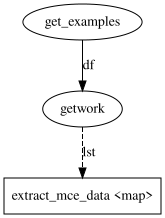

In [19]:


from os import listdir
from os.path import isfile, join
from common import file_ops

@task(log_stdout=True, tags=["snowflake_small"])
def extract_mce_data(local_folder_v2_enrich, lst, dte_run, sf_warehouse, core_query, acat_tbl, notes_tbl):
    req = lst[0]
    cust = lst[1]
    ref_name = f"{lst[2]}_{lst[3]}".lower()
    this_fn_data_out_path = file_ops.prep_data_location(os.path.join(local_folder_v2_enrich, dte_run, str(req)), clear_contents=False)
    
    dir_list = os.listdir(this_fn_data_out_path)
    
    print(f"Starting extract_acat_data for {req}  @@ {this_fn_data_out_path} ")
    if not os.path.isdir(this_fn_data_out_path) or len(dir_list)==0:

        this_query = core_query.format(src_file_name=ref_name, acat_table=acat_tbl, notes_table=notes_tbl, req=req)
        print(this_query)

        engine = create_engine(sec.get_sf_pw('prd_cps_dsci_etl_svc', sf_warehouse, 'CPS_DSCI_STG'))

        letters = string.ascii_letters
        snowflake_temp_loc = 'culvert_stage_{}'.format(''.join(random.choice(letters) for i in range(25)))

        con = engine.connect()
        resultsS = con.execute("USE {db}.{schema}".format(db=snowflake_db, schema='CPS_DSCI_STG'))
        resultsW = con.execute("USE warehouse {}".format(sf_warehouse)).fetchall()
        cmd = "create or replace temporary stage {tmp_name} file_format=(TYPE = PARQUET compression=snappy)".format(
            tmp_name=snowflake_temp_loc)
        resultsT = pd.DataFrame(con.execute(cmd).fetchall())
        print(resultsT)


        cmd = """copy into @{tmp_name}/ from ( {this_query}
             )
              file_format = (type = 'parquet')
              header = true;
            """.format(tmp_name=snowflake_temp_loc, this_query=this_query)

        resultsT = pd.DataFrame(con.execute(cmd).fetchall())
        print(resultsT)

        print(this_fn_data_out_path, snowflake_temp_loc)

        con.execute("GET @{tmp_name} file://{landing_folder}".format(tmp_name=snowflake_temp_loc,
                                                                     landing_folder=this_fn_data_out_path))

        con.close()
        engine.dispose()

@task(log_stdout=True)  
def get_examples(tbl):
    engine = create_engine(sec.get_sf_pw('prd_cps_dsci_etl_svc', 'CPS_DSCI_ETL_WH', 'CPS_DSCI_STG'))
    examples = f"""select distinct f.ACAT_REQUEST_ID ,
                 to_char(f.FILE_NAME_DATE,'YYYY_MM_DD') as file_name_date,
                 f.SWEEPS_CUSTOMER_NAME,
                 f.FILE_NAME_CUSTOMER_ID from {tbl} f"""
    print(examples)
    real_data = pd.read_sql(examples, engine)    
    real_data['customer_name_mod'] = real_data.apply(lambda x: clean_name(x['sweeps_customer_name']), axis=1)
    return real_data
 
import re    
def clean_name(fld):
    return re.sub('[^0-9a-zA-Z]+', '_', fld)

    
    
@task(log_stdout=True)    
def getwork(df):
    lotup = [] #list of tuples for work to map
    for i, row in df.iterrows():
        lotup.append([ row.acat_request_id,row.file_name_customer_id, row.customer_name_mod, row.file_name_date  ])
    return lotup   

core_query = """select f.*,
                       1 as canvas_source_file_{src_file_name} ,
                       case when n.INSTANCE_ID is null then 'single'
                            else 'multi_line_fix' end as modified_record,
                       n.notes as note
            from {acat_table} f
            left join {notes_table}  n on (n.INSTANCE_ID=f.INSTANCE_ID and n.ACAT_REQUEST_ID=f.ACAT_REQUEST_ID)
            where f.ACAT_REQUEST_ID ={req} and ROW_NUM_CLI =1"""


with Flow(
        "snatch data",
        #storage=storage_obj,
        run_config=KubernetesRun(memory_request=60000000000),
        # executor=LocalDaskExecutor(scheduler="processes", num_workers=psutil.cpu_count(logical=True)),
        executor=LocalDaskExecutor(scheduler="processes", num_workers=20),
        result=S3Result(bucket="cam-prefect-results")
) as flow:
    segment = Parameter("segment")
    #lotup is the mapped work
    local_folder_v2_enrich = "/mnt/newmt/ERP/home/alanzen/ACAT/RE_ENRICH_3"
    dte_run =this_date_mod_str  # as a damn string!!!
    sf_warehouse = 'CPS_DSCI_ETL_EXT2_WH'
    snowflake_db = "CPS_DB"
    batch_val =this_date_mod_str
    segment = 1
    acat_tbl = f'''CPS_DSCI_ARCHIVE.test_acat_evidence_b_{batch_val}_to_file_{segment}'''
    notes_tbl = f'''CPS_DSCI_ARCHIVE.acat_notes_b_{batch_val}_to_s{segment}'''


    examples = get_examples(acat_tbl)
    lotup = getwork(examples)
    extract_mce_data.map(
        local_folder_v2_enrich= unmapped(local_folder_v2_enrich), 
        lst=lotup, 
        dte_run = unmapped(dte_run), 
        sf_warehouse= unmapped(sf_warehouse), 
        core_query= unmapped(core_query),
        acat_tbl= unmapped(acat_tbl), 
        notes_tbl=unmapped(notes_tbl)
    )
    
flow.visualize()




# this_date = pd.to_datetime("today")
# this_date_str = this_date.strftime("%Y-%m-%d")
# this_date_mod_str = this_date.strftime("%Y_%m_%d")
# dest_folder = os.path.join('/mnt/newmt/ERP/home/alanzen/ACAT_SRC/',this_date_mod_str)
# destination_loc = '/tmp/ramdisk/culvert_stage_LXtirVTsMI'
# dest_table = f'ACAT_EVIDENCE_part_{this_date_mod_str}'.lower()


In [20]:
flow.run()
flow.run()

[2023-02-13 23:09:03+0000] INFO - prefect.FlowRunner | Beginning Flow run for 'snatch data'
[2023-02-13 23:09:04+0000] INFO - prefect.TaskRunner | Task 'get_examples': Starting task run...
[2023-02-13 23:09:04+0000] INFO - prefect.TaskRunner | select distinct f.ACAT_REQUEST_ID ,
                 to_char(f.FILE_NAME_DATE,'YYYY_MM_DD') as file_name_date,
                 f.SWEEPS_CUSTOMER_NAME,
                 f.FILE_NAME_CUSTOMER_ID from CPS_DSCI_ARCHIVE.test_acat_evidence_b_2023_02_13_to_file_1 f
[2023-02-13 23:09:08+0000] INFO - prefect.TaskRunner | Task 'get_examples': Finished task run for task with final state: 'Success'
[2023-02-13 23:09:08+0000] INFO - prefect.TaskRunner | Task 'getwork': Starting task run...
[2023-02-13 23:09:08+0000] INFO - prefect.TaskRunner | Task 'getwork': Finished task run for task with final state: 'Success'
[2023-02-13 23:09:09+0000] INFO - prefect.TaskRunner | Task 'extract_mce_data': Starting task run...
[2023-02-13 23:09:09+0000] INFO - prefect.TaskR

/home/alanzen/.cache/pypoetry/virtualenvs/hnms-aws-F0wIgF5s-py3.8/lib/python3.8/site-packages/snowflake/connector/options.py:96: UserWarning: You have an incompatible version of 'pyarrow' installed (3.0.0), please install a version that adheres to: 'pyarrow<6.1.0,>=6.0.0; extra == "pandas"'
  warn_incompatible_dep(
/home/alanzen/.cache/pypoetry/virtualenvs/hnms-aws-F0wIgF5s-py3.8/lib/python3.8/site-packages/snowflake/connector/options.py:96: UserWarning: You have an incompatible version of 'pyarrow' installed (3.0.0), please install a version that adheres to: 'pyarrow<6.1.0,>=6.0.0; extra == "pandas"'
  warn_incompatible_dep(
/home/alanzen/.cache/pypoetry/virtualenvs/hnms-aws-F0wIgF5s-py3.8/lib/python3.8/site-packages/snowflake/connector/options.py:96: UserWarning: You have an incompatible version of 'pyarrow' installed (3.0.0), please install a version that adheres to: 'pyarrow<6.1.0,>=6.0.0; extra == "pandas"'
  warn_incompatible_dep(
/home/alanzen/.cache/pypoetry/virtualenvs/hnms-aw

[2023-02-13 23:15:38+0000] INFO - prefect.FlowRunner | Flow run SUCCESS: all reference tasks succeeded
[2023-02-13 23:15:38+0000] INFO - prefect.FlowRunner | Beginning Flow run for 'snatch data'
[2023-02-13 23:15:40+0000] INFO - prefect.TaskRunner | Task 'get_examples': Starting task run...
[2023-02-13 23:15:40+0000] INFO - prefect.TaskRunner | select distinct f.ACAT_REQUEST_ID ,
                 to_char(f.FILE_NAME_DATE,'YYYY_MM_DD') as file_name_date,
                 f.SWEEPS_CUSTOMER_NAME,
                 f.FILE_NAME_CUSTOMER_ID from CPS_DSCI_ARCHIVE.test_acat_evidence_b_2023_02_13_to_file_1 f
[2023-02-13 23:15:41+0000] INFO - prefect.TaskRunner | Task 'get_examples': Finished task run for task with final state: 'Success'
[2023-02-13 23:15:42+0000] INFO - prefect.TaskRunner | Task 'getwork': Starting task run...
[2023-02-13 23:15:42+0000] INFO - prefect.TaskRunner | Task 'getwork': Finished task run for task with final state: 'Success'
[2023-02-13 23:15:43+0000] INFO - prefect.Tas

/home/alanzen/.cache/pypoetry/virtualenvs/hnms-aws-F0wIgF5s-py3.8/lib/python3.8/site-packages/snowflake/connector/options.py:96: UserWarning: You have an incompatible version of 'pyarrow' installed (3.0.0), please install a version that adheres to: 'pyarrow<6.1.0,>=6.0.0; extra == "pandas"'
  warn_incompatible_dep(


[2023-02-13 23:15:46+0000] INFO - prefect.FlowRunner | Flow run SUCCESS: all reference tasks succeeded


<Success: "All reference tasks succeeded.">

In [21]:

# use warehouse CPS_DSCI_ETL_EXT3_WH;


# create table CPS_DSCI_ARCHIVE.ACAT_SCOPE as
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_4 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_5 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_6 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_7 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_8 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_9 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_10 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_11 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_07_15 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_07_18 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_07_19 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_07_20 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_07_21 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_07_22 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_07_25 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_07_27 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_07_28 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_07_29 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_08_01 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_08_03 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_08_04 e
# union
# select distinct e.ACAT_REQUEST_ID, e.FILE_NAME_CUSTOMER_ID,  e.INSTANCE_ID from CPS_DSCI_ARCHIVE.ACAT_EVIDENCE_PART_2022_08_05 e
# ;


In [22]:
def gen_display_name(f1, f2):
    return f"{f1}_{f2}"

def check_env(env):
    print(env)
    if env == "dev":
        cn = "dev_cps_dsci_etl_svc"
    elif env == "stage":
        cn = "stg_cps_dsci_etl_svc"
    elif env == "prod":
        cn = "prd_cps_dsci_etl_svc"
    return cn

 
import re    
def clean_name(fld):
    return re.sub('[^0-9a-zA-Z]+', '_', fld)

# this_date = pd.to_datetime("today")
# this_date_str = this_date.strftime("%Y-%m-%d")
# this_date_mod_str = this_date.strftime("%Y_%m_%d")
# dest_folder = os.path.join('/mnt/newmt/ERP/home/alanzen/ACAT_SRC/',this_date_mod_str)
# destination_loc = '/tmp/ramdisk/culvert_stage_LXtirVTsMI'
# dest_table = f'ACAT_EVIDENCE_part_',{this_date_mod_str}'.lower()

dte_run = this_date_mod_str
batch_val = this_date_mod_str
segment = 1
acat_tbl = f'''CPS_DSCI_ARCHIVE.test_acat_evidence_b_{batch_val}_to_file_{segment}'''
notes_tbl = f'''CPS_DSCI_ARCHIVE.acat_notes_b_{this_date_mod_str}_to_s{segment}''' 
#----------------------------------------------------------
engine = create_engine(sec.get_sf_pw('prd_cps_dsci_etl_svc', 'CPS_DSCI_ETL_EXT1_WH', 'CPS_DSCI_STG'))

sql= f"""
    select
         FILE_NAME_CUSTOMER_ID as customer_id, FILE_NAME_DATE as creation_date, FILE_NAME_ACAT_REQUEST_ID as request_id,
        f.SWEEPS_CUSTOMER_NAME, f.ACAT_REQUEST_ID, '{dte_run}' as src_date  ,
               concat('s3://canvas-data-store-prod/ACAT_PREPPED_FILES/{dte_run}/',
               f.ACAT_REQUEST_ID,'/{dte_run}/full/') as file_path,
               count(0) as row_cnt
        from {acat_tbl} f
    where ROW_NUM_CLI =1
        group by f.ACAT_REQUEST_ID, f.SWEEPS_CUSTOMER_NAME, '{dte_run}',
                concat('s3://canvas-data-store-prod/ACAT_PREPPED_FILES/{dte_run}/',f.ACAT_REQUEST_ID,'/{dte_run}/full/'),
                FILE_NAME_CUSTOMER_ID , FILE_NAME_DATE , FILE_NAME_ACAT_REQUEST_ID
           """

print(sql)

engagements = pd.read_sql(sql, engine)
engagements['engagement_name_mod'] = engagements.apply(lambda x: clean_name(x['sweeps_customer_name']), axis=1)
engagements['acat_request_id'] = engagements['acat_request_id'].astype("Int64")
engagements['customer_id'] = engagements['customer_id'].astype("Int64")
engagements['display_name'] = engagements.apply(lambda x: gen_display_name(x['engagement_name_mod'],x['creation_date']), axis=1)
engagements
#engagements.reset_index(drop=False, inplace=True)



    select
         FILE_NAME_CUSTOMER_ID as customer_id, FILE_NAME_DATE as creation_date, FILE_NAME_ACAT_REQUEST_ID as request_id,
        f.SWEEPS_CUSTOMER_NAME, f.ACAT_REQUEST_ID, '2023_02_13' as src_date  ,
               concat('s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/',
               f.ACAT_REQUEST_ID,'/2023_02_13/full/') as file_path,
               count(0) as row_cnt
        from CPS_DSCI_ARCHIVE.test_acat_evidence_b_2023_02_13_to_file_1 f
    where ROW_NUM_CLI =1
        group by f.ACAT_REQUEST_ID, f.SWEEPS_CUSTOMER_NAME, '2023_02_13',
                concat('s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/',f.ACAT_REQUEST_ID,'/2023_02_13/full/'),
                FILE_NAME_CUSTOMER_ID , FILE_NAME_DATE , FILE_NAME_ACAT_REQUEST_ID
           


,customer_id,creation_date,request_id,sweeps_customer_name,acat_request_id,src_date,file_path,row_cnt,engagement_name_mod,display_name
0,1676047571078,2023-02-10,1676049393457,ATRUVIA AG TEST SCOPE,1676049393457,2023_02_13,s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676049393457/2023_02_13/full/,25635,ATRUVIA_AG_TEST_SCOPE,ATRUVIA_AG_TEST_SCOPE_2023-02-10
1,1676285746083,2023-02-13,1676300697230,OEBB_SFC,1676300697230,2023_02_13,s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676300697230/2023_02_13/full/,354422,OEBB_SFC,OEBB_SFC_2023-02-13
2,1602117894636,2023-02-13,1676309017249,AFCENT,1676309017249,2023_02_13,s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676309017249/2023_02_13/full/,138641,AFCENT,AFCENT_2023-02-13
3,1652110245763,2023-02-13,1676307954592,IKEA - INGKA,1676307954592,2023_02_13,s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676307954592/2023_02_13/full/,339247,IKEA_INGKA,IKEA_INGKA_2023-02-13
4,1642526181747,2023-02-13,1676308673638,NYC HHC,1676308673638,2023_02_13,s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676308673638/2023_02_13/full/,175935,NYC_HHC,NYC_HHC_2023-02-13
5,1632753727688,2023-02-10,1676035449286,MASTERCARD,1676035449286,2023_02_13,s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676035449286/2023_02_13/full/,253636,MASTERCARD,MASTERCARD_2023-02-10
6,1657015064713,2023-02-10,1676029857658,TETRA PAK AB,1676029857658,2023_02_13,s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676029857658/2023_02_13/full/,111316,TETRA_PAK_AB,TETRA_PAK_AB_2023-02-10
7,1661419651168,2023-02-10,1676058306779,HQDA G2,1676058306779,2023_02_13,s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676058306779/2023_02_13/full/,42506,HQDA_G2,HQDA_G2_2023-02-10
8,1628671282870,2023-02-13,1676290140754,ASML - US,1676290140754,2023_02_13,s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676290140754/2023_02_13/full/,11308,ASML_US,ASML_US_2023-02-13
9,1667408846983,2023-02-13,1676303526981,TELENOR SVERIGE AB FY23,1676303526981,2023_02_13,s3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676303526981/2023_02_13/full/,107484,TELENOR_SVERIGE_AB_FY23,TELENOR_SVERIGE_AB_FY23_2023-02-13


In [23]:
#for i, row in ee.iterrows():
for i, row in engagements.iterrows():
    print(i)
    loc  = os.path.join(f'/mnt/newmt/ERP/home/alanzen/ACAT/RE_ENRICH_3/{dte_run}',str(row.acat_request_id))
    if os.path.isdir(loc):
        files_to_move = os.listdir(loc)
        OBJ_TO_delete = wr.s3.list_objects(row.file_path)
        for otd in OBJ_TO_delete:
            print(f"del: {otd}")
            wr.s3.delete_objects(otd)
        for f in files_to_move:
            #print(os.path.join(loc, f) , os.path.join(row.file_path, f))
            wr.s3.upload(local_file=os.path.join(loc, f) , path=os.path.join(row.file_path, f))

        if len(files_to_move) > 0:
            engine = create_engine(sec.get_sf_pw(check_env('prod'), 'CPS_DSCI_ETL_EXT1_WH', 'CPS_DSCI_ARCHIVE'))
            con = engine.connect()
            cust_id = row.customer_id
            engagement_id=row.acat_request_id
            file_name='*.parquet'
            full_canvas_out_pth=row.file_path
            file_type='all'
            num_records=row.row_cnt
            date_sourced = row.creation_date
            last_processed_date= dte_run.replace('_','-')
            display_name=row.display_name
            engagement_id=row.acat_request_id


            update_metadata_query = f"""MERGE INTO CPS_DB.CPS_BIA_BR.DATA_CANVAS_DATA_SOURCES d
                  USING (
                    SELECT '{cust_id}' AS REMOTE_SYSTEM_CUSTOMER_IDENTIFIER,
                    '{file_name}' AS FILE_NAME,
                    '{full_canvas_out_pth}' AS FOLDER_PATH,
                    'ACAT' AS FILE_SOURCE,
                    'all' AS FILE_TYPE,
                    {num_records} AS NUM_RECORDS,
                    '{date_sourced}' AS DATE_SOURCED,
                    '{last_processed_date}' AS LAST_PROCESSED_DATE,
                    'acat_customer_id' AS REMOTE_SYSTEM,
                     '{display_name}' AS DISPLAY_NAME,
                    '{engagement_id}' AS REQUEST_ID
                 ) s ON d.REMOTE_SYSTEM = s.REMOTE_SYSTEM AND d.REQUEST_ID = s.REQUEST_ID
              WHEN MATCHED THEN update SET
                  d.DISPLAY_NAME = s.DISPLAY_NAME, d.LAST_PROCESSED_DATE = s.LAST_PROCESSED_DATE,
                  d.DATE_SOURCED = s.DATE_SOURCED, d.NUM_RECORDS = s.NUM_RECORDS, d.FILE_TYPE = s.FILE_TYPE,
                  d.FILE_SOURCE = s.FILE_SOURCE, d.FOLDER_PATH = s.FOLDER_PATH, d.FILE_NAME = s.FILE_NAME,
                  d.REMOTE_SYSTEM_CUSTOMER_IDENTIFIER = s.REMOTE_SYSTEM_CUSTOMER_IDENTIFIER, d.REMOTE_SYSTEM=s.REMOTE_SYSTEM
              WHEN NOT MATCHED THEN INSERT(REMOTE_SYSTEM_CUSTOMER_IDENTIFIER,FILE_NAME,FOLDER_PATH,FILE_SOURCE,FILE_TYPE,NUM_RECORDS,
                                          DATE_SOURCED,LAST_PROCESSED_DATE,REMOTE_SYSTEM,DISPLAY_NAME,REQUEST_ID)
              VALUES (s.REMOTE_SYSTEM_CUSTOMER_IDENTIFIER, s.FILE_NAME, s.FOLDER_PATH, s.FILE_SOURCE, s.FILE_TYPE,
                      s.NUM_RECORDS,s.DATE_SOURCED,s.LAST_PROCESSED_DATE, s.REMOTE_SYSTEM,s.DISPLAY_NAME, s.REQUEST_ID)"""




            print(update_metadata_query)
            con.execute(update_metadata_query)
            con.close()


0
prod
MERGE INTO CPS_DB.CPS_BIA_BR.DATA_CANVAS_DATA_SOURCES d
                  USING (
                    SELECT '1676047571078' AS REMOTE_SYSTEM_CUSTOMER_IDENTIFIER,
                    '*.parquet' AS FILE_NAME,
                    's3://canvas-data-store-prod/ACAT_PREPPED_FILES/2023_02_13/1676049393457/2023_02_13/full/' AS FOLDER_PATH,
                    'ACAT' AS FILE_SOURCE,
                    'all' AS FILE_TYPE,
                    25635 AS NUM_RECORDS,
                    '2023-02-10' AS DATE_SOURCED,
                    '2023-02-13' AS LAST_PROCESSED_DATE,
                    'acat_customer_id' AS REMOTE_SYSTEM,
                     'ATRUVIA_AG_TEST_SCOPE_2023-02-10' AS DISPLAY_NAME,
                    '1676049393457' AS REQUEST_ID
                 ) s ON d.REMOTE_SYSTEM = s.REMOTE_SYSTEM AND d.REQUEST_ID = s.REQUEST_ID
              WHEN MATCHED THEN update SET
                  d.DISPLAY_NAME = s.DISPLAY_NAME, d.LAST_PROCESSED_DATE = s.LAST_PROCESSED_DATE,
              

In [24]:
! mv /tmp/ramdisk/tmp_ram_drive/*.parquet /mnt/newmt/ERP/home/alanzen/ACAT_FILES_PREPPED/.

In [25]:
! ls /tmp/ramdisk/tmp_ram_drive/